<a href="https://colab.research.google.com/github/Sriharan-Thirumurthi/MST-Project/blob/main/monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

directory = "/content/drive/MyDrive/new_stock_data"
stock_data = {}
def detect_outliers_iqr(data, column):
    """Detect outliers using the IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
# Load only available stock data
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        stock_name = filename.replace(".csv", "")  # Extract stock symbol from filename
        file_path = os.path.join(directory, filename)

        try:
            df = pd.read_csv(file_path, parse_dates=["Date"], index_col="Date")
            stock_data[stock_name] = df
            print(f"✅ Loaded data for {stock_name}")
        except Exception as e:
            print(f"⚠️ Error loading {filename}: {e}")

print(f"📊 Successfully loaded {len(stock_data)} stock datasets.")


✅ Loaded data for GC=F
✅ Loaded data for NIFTYBEES.NS
✅ Loaded data for ORCL
✅ Loaded data for NVDA
✅ Loaded data for META
✅ Loaded data for BHARTIARTL.NS
✅ Loaded data for GE
✅ Loaded data for AAPL
✅ Loaded data for WMT
✅ Loaded data for LT.NS
✅ Loaded data for ABBV
✅ Loaded data for POWERGRID.NS
✅ Loaded data for BPCL.NS
✅ Loaded data for NFLX
✅ Loaded data for JSWSTEEL.NS
✅ Loaded data for BTC-USD
✅ Loaded data for TATASTEEL.NS
✅ Loaded data for COALINDIA.NS
✅ Loaded data for ICICIBANK.NS
✅ Loaded data for JPM
✅ Loaded data for HCLTECH.NS
✅ Loaded data for HEROMOTOCO.NS
✅ Loaded data for V
✅ Loaded data for ADANIPORTS.NS
✅ Loaded data for BRITANNIA.NS
✅ Loaded data for ULTRACEMCO.NS
✅ Loaded data for SUNPHARMA.NS
✅ Loaded data for XOM
✅ Loaded data for NTPC.NS
✅ Loaded data for BRK-B
✅ Loaded data for SBIN.NS
✅ Loaded data for MARUTI.NS
✅ Loaded data for CIPLA.NS
✅ Loaded data for SETFNIF50.NS
✅ Loaded data for IBM
✅ Loaded data for COCHINSHIP.BO
✅ Loaded data for MA
✅ Loaded data f

In [ ]:
def cap_outliers(data, stock_name):
    """Cap outliers for a given stock using the IQR method."""
    column = f'Close_{stock_name}'

    if column not in data.columns:
        print(f"❌ Column '{column}' not found in dataset. Skipping {stock_name}.")
        return data  # Return unchanged data

    outliers, lower_bound, upper_bound = detect_outliers_iqr(data, column)

    # Cap outliers
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)

    print(f"✅ Outliers capped for {stock_name}. ({len(outliers)} detected)")
    return data

# List of stocks with outliers
outlier_stocks = ["BRITANNIA.NS", "TATASTEEL.NS", "V", "XOM", "WMT"]

# Apply outlier capping in memory
for stock in outlier_stocks:
    if stock in stock_data:
        stock_data[stock] = cap_outliers(stock_data[stock], stock)
    else:
        print(f"⚠️ Data not available for {stock}, skipping.")

print("✅ Outliers capped for all mentioned stocks. Moving to SARIMAX forecasting...")


✅ Outliers capped for BRITANNIA.NS. (1 detected)
✅ Outliers capped for TATASTEEL.NS. (2 detected)
✅ Outliers capped for V. (1 detected)
✅ Outliers capped for XOM. (1 detected)
✅ Outliers capped for WMT. (2 detected)
✅ Outliers capped for all mentioned stocks. Moving to SARIMAX forecasting...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_forecast(stock_name, df, forecast_periods=13):
    """Run SARIMAX forecasting and plot results."""

    close_col = f"Close_{stock_name}"
    df = df.copy()  # Work on a copy to avoid modifying original data

    # Train-Test Split (Using all data for training)
    df_train = df[[close_col]]

    # Fit SARIMAX Model
    model = SARIMAX(df_train[close_col], order=(1,1,3), seasonal_order=(1,1,2,12))
    model_fit = model.fit()

    # Forecast Future Prices
    forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_periods + 1, freq='M')[1:]
    forecast = model_fit.forecast(steps=forecast_periods)

    df_forecast = pd.DataFrame({ "Date": forecast_dates, close_col: forecast })
    df_forecast.set_index("Date", inplace=True)

    # Plot Results
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[close_col], label="Historical Prices", color='blue', marker='o')
    plt.plot(df_forecast.index, df_forecast[close_col], label="Forecasted Prices", color='red', marker='x')
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.title(f"SARIMAX Forecast for {stock_name}")
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

    return df_forecast


In [ ]:
import numpy as np

def compute_metrics(stock_name, df_hist, df_forecast, risk_free_rate_hist=0.07, risk_free_rate_forecast=0.07):
    """Compute financial metrics for historical and forecasted data."""

    close_col = f"Close_{stock_name}"

    # Daily Returns
    df_hist["Daily Return"] = df_hist[close_col].pct_change()
    df_forecast["Daily Return"] = df_forecast[close_col].pct_change()

    # Annualized Return
    annual_return_hist = ((df_hist[close_col].iloc[-1] / df_hist[close_col].iloc[0]) ** (1/3)) - 1  # CAGR for 3 years
    annual_return_forecast = ((df_forecast[close_col].iloc[-1] / df_forecast[close_col].iloc[0]) ** (1/1)) - 1  # 1 year CAGR

    # Cumulative Return
    cumulative_return_hist = df_hist[close_col].iloc[-1] / df_hist[close_col].iloc[0] - 1
    cumulative_return_forecast = df_forecast[close_col].iloc[-1] / df_forecast[close_col].iloc[0] - 1

    # Annualized Volatility
    volatility_hist = df_hist["Daily Return"].std() * np.sqrt(252)
    volatility_forecast = df_forecast["Daily Return"].std() * np.sqrt(12)  # Forecasting only for 12 months

    # Sharpe Ratio
    sharpe_ratio_hist = (annual_return_hist - risk_free_rate_hist) / volatility_hist
    sharpe_ratio_forecast = (annual_return_forecast - risk_free_rate_forecast) / volatility_forecast

    # Print Results
    print(f"\n📊 Financial Metrics for {stock_name}")
    print("-------------------------------------------------")
    print(f"Annualized Return (Historical): {annual_return_hist:.4f}")
    print(f"Annualized Return (Forecasted): {annual_return_forecast:.4f}")
    print(f"Cumulative Return (Historical): {cumulative_return_hist:.4f}")
    print(f"Cumulative Return (Forecasted): {cumulative_return_forecast:.4f}")
    print(f"Annualized Volatility (Historical): {volatility_hist:.4f}")
    print(f"Annualized Volatility (Forecasted): {volatility_forecast:.4f}")
    print(f"Sharpe Ratio (Historical): {sharpe_ratio_hist:.4f}")
    print(f"Sharpe Ratio (Forecasted): {sharpe_ratio_forecast:.4f}")

    return {
        "Annualized Return (Hist)": annual_return_hist,
        "Annualized Return (Forecast)": annual_return_forecast,
        "Cumulative Return (Hist)": cumulative_return_hist,
        "Cumulative Return (Forecast)": cumulative_return_forecast,
        "Annualized Volatility (Hist)": volatility_hist,
        "Annualized Volatility (Forecast)": volatility_forecast,
        "Sharpe Ratio (Hist)": sharpe_ratio_hist,
        "Sharpe Ratio (Forecast)": sharpe_ratio_forecast
    }



🚀 Running SARIMAX for GC=F...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization

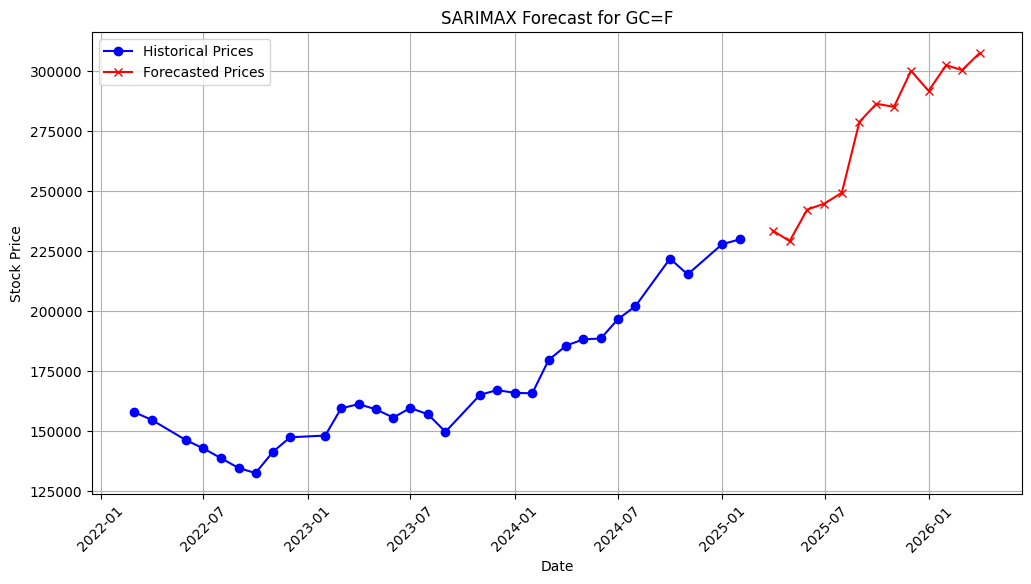


📊 Financial Metrics for GC=F
-------------------------------------------------
Annualized Return (Historical): 0.1332
Annualized Return (Forecasted): 0.3165
Cumulative Return (Historical): 0.4554
Cumulative Return (Forecasted): 0.3165
Annualized Volatility (Historical): 0.6737
Annualized Volatility (Forecasted): 0.1382
Sharpe Ratio (Historical): 0.0939
Sharpe Ratio (Forecasted): 1.7839

🚀 Running SARIMAX for NIFTYBEES.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

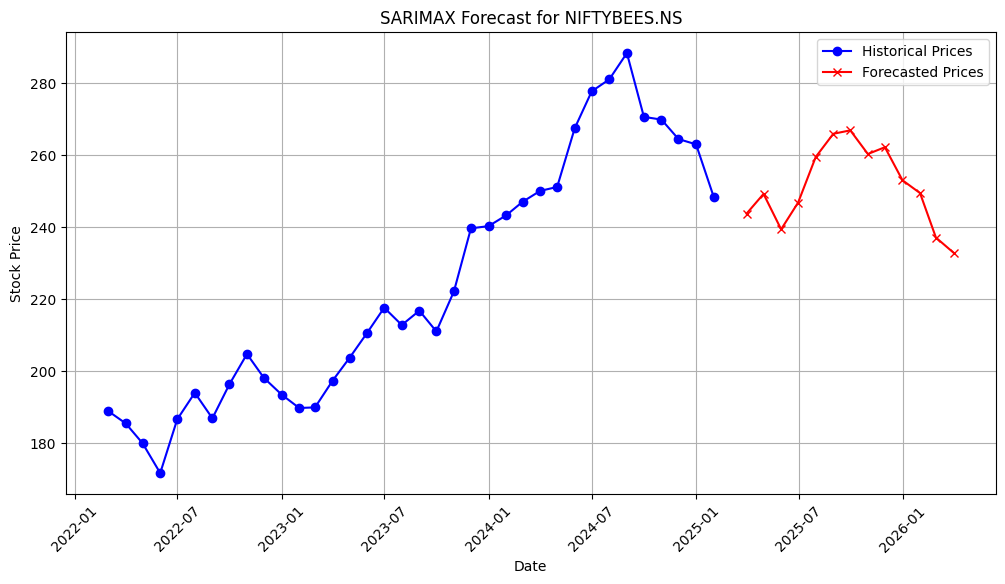


📊 Financial Metrics for NIFTYBEES.NS
-------------------------------------------------
Annualized Return (Historical): 0.0957
Annualized Return (Forecasted): -0.0445
Cumulative Return (Historical): 0.3155
Cumulative Return (Forecasted): -0.0445
Annualized Volatility (Historical): 0.5928
Annualized Volatility (Forecasted): 0.1097
Sharpe Ratio (Historical): 0.0434
Sharpe Ratio (Forecasted): -1.0442

🚀 Running SARIMAX for ORCL...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_periods + 1, freq='M')[1:]


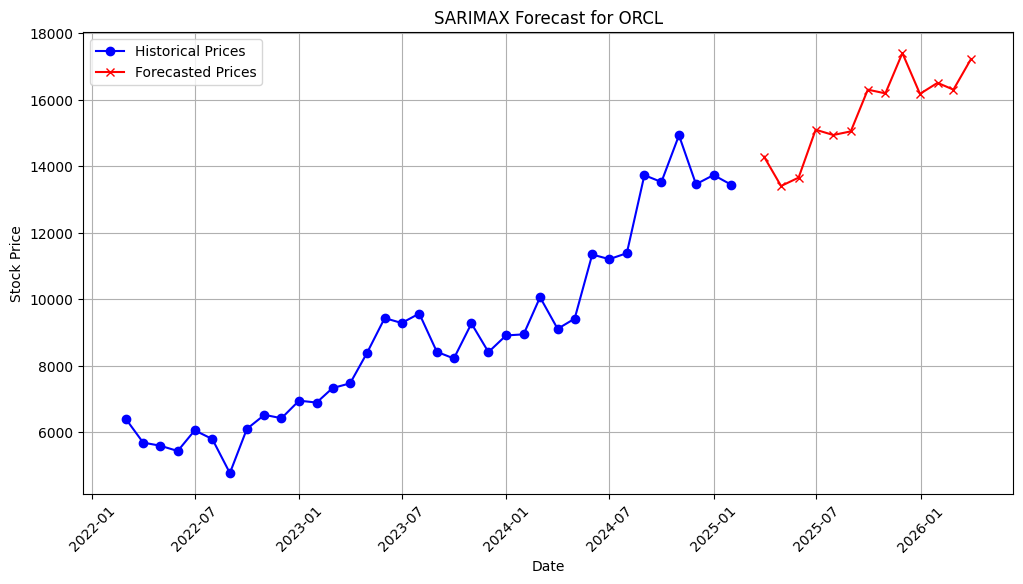


📊 Financial Metrics for ORCL
-------------------------------------------------
Annualized Return (Historical): 0.2797
Annualized Return (Forecasted): 0.2055
Cumulative Return (Historical): 1.0958
Cumulative Return (Forecasted): 0.2055
Annualized Volatility (Historical): 1.5807
Annualized Volatility (Forecasted): 0.1906
Sharpe Ratio (Historical): 0.1327
Sharpe Ratio (Forecasted): 0.7108

🚀 Running SARIMAX for NVDA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

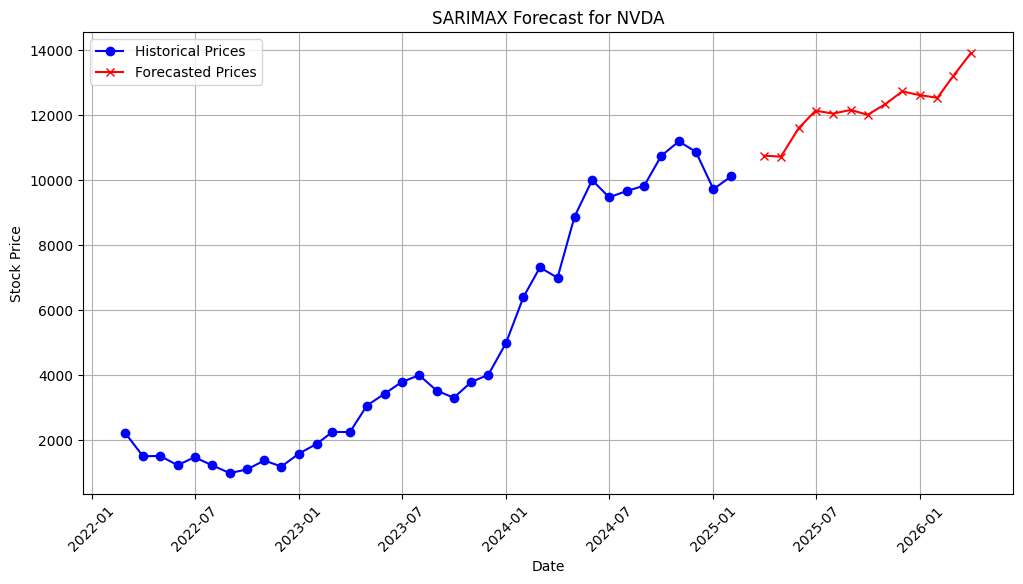


📊 Financial Metrics for NVDA
-------------------------------------------------
Annualized Return (Historical): 0.6614
Annualized Return (Forecasted): 0.2936
Cumulative Return (Historical): 3.5858
Cumulative Return (Forecasted): 0.2936
Annualized Volatility (Historical): 2.5756
Annualized Volatility (Forecasted): 0.1086
Sharpe Ratio (Historical): 0.2296
Sharpe Ratio (Forecasted): 2.0587

🚀 Running SARIMAX for META...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

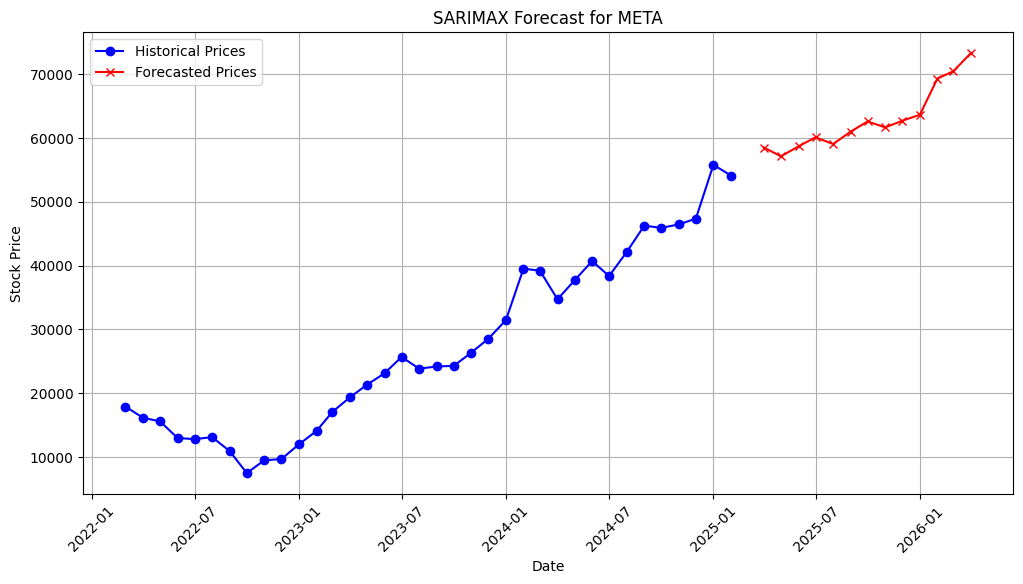


📊 Financial Metrics for META
-------------------------------------------------
Annualized Return (Historical): 0.4449
Annualized Return (Forecasted): 0.2529
Cumulative Return (Historical): 2.0165
Cumulative Return (Forecasted): 0.2529
Annualized Volatility (Historical): 1.9992
Annualized Volatility (Forecasted): 0.1047
Sharpe Ratio (Historical): 0.1875
Sharpe Ratio (Forecasted): 1.7474

🚀 Running SARIMAX for BHARTIARTL.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

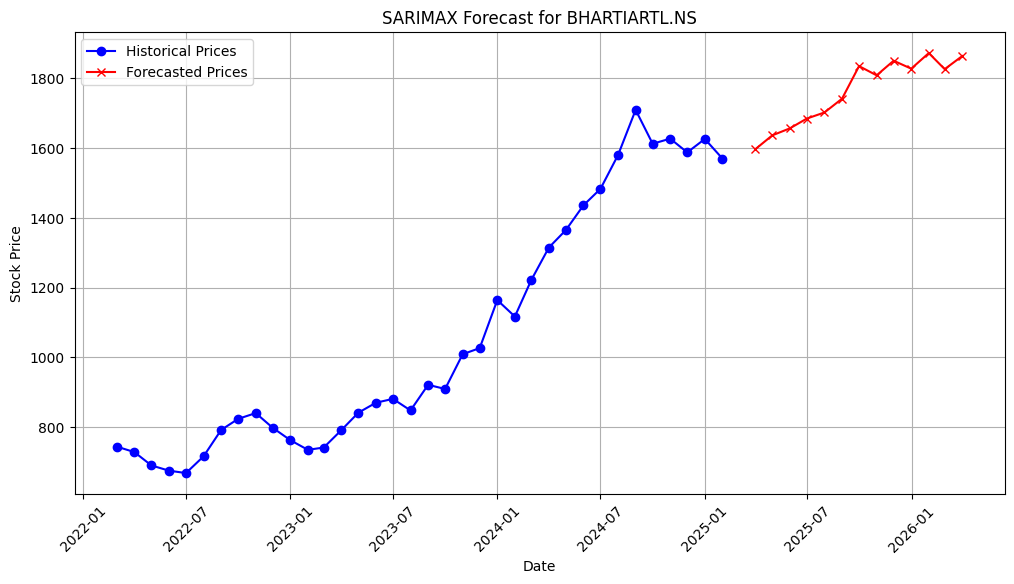


📊 Financial Metrics for BHARTIARTL.NS
-------------------------------------------------
Annualized Return (Historical): 0.2827
Annualized Return (Forecasted): 0.1674
Cumulative Return (Historical): 1.1104
Cumulative Return (Forecasted): 0.1674
Annualized Volatility (Historical): 0.8480
Annualized Volatility (Forecasted): 0.0740
Sharpe Ratio (Historical): 0.2508
Sharpe Ratio (Forecasted): 1.3161

🚀 Running SARIMAX for GE...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

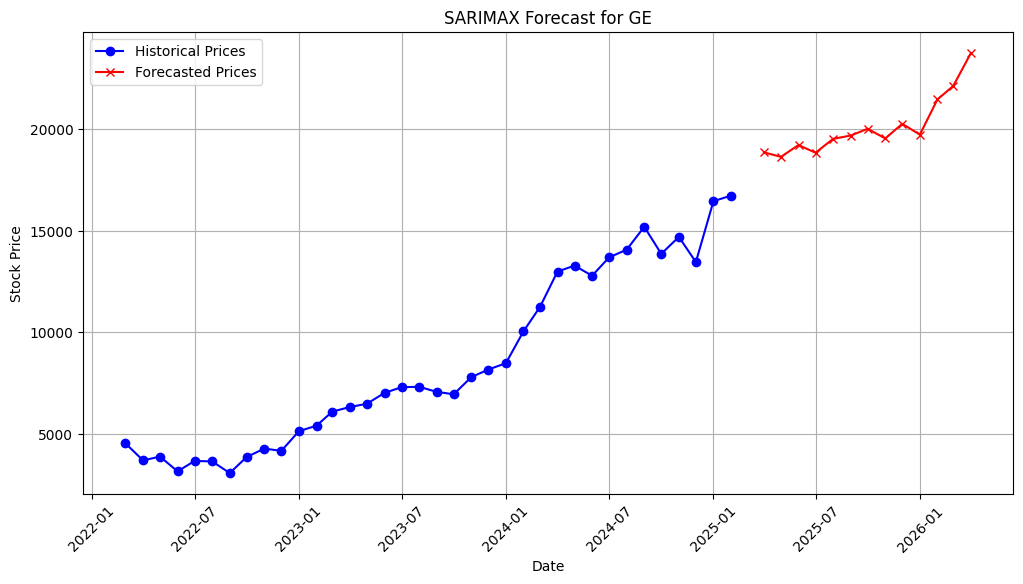


📊 Financial Metrics for GE
-------------------------------------------------
Annualized Return (Historical): 0.5441
Annualized Return (Forecasted): 0.2588
Cumulative Return (Historical): 2.6816
Cumulative Return (Forecasted): 0.2588
Annualized Volatility (Historical): 1.7056
Annualized Volatility (Forecasted): 0.1277
Sharpe Ratio (Historical): 0.2780
Sharpe Ratio (Forecasted): 1.4791

🚀 Running SARIMAX for AAPL...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_periods + 1, freq='M')[1:]


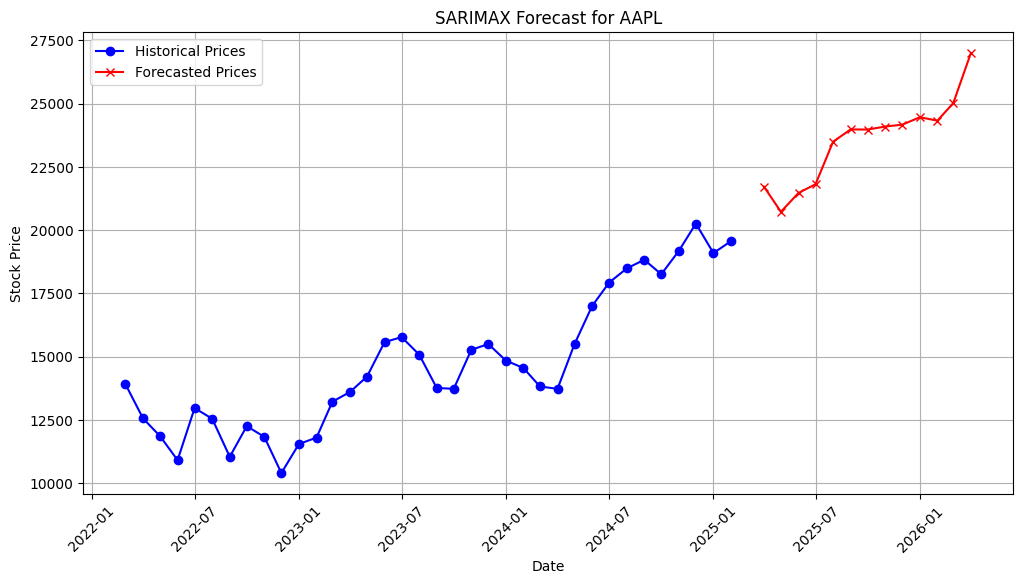


📊 Financial Metrics for AAPL
-------------------------------------------------
Annualized Return (Historical): 0.1203
Annualized Return (Forecasted): 0.2429
Cumulative Return (Historical): 0.4059
Cumulative Return (Forecasted): 0.2429
Annualized Volatility (Historical): 1.2161
Annualized Volatility (Forecasted): 0.1192
Sharpe Ratio (Historical): 0.0413
Sharpe Ratio (Forecasted): 1.4507

🚀 Running SARIMAX for WMT...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

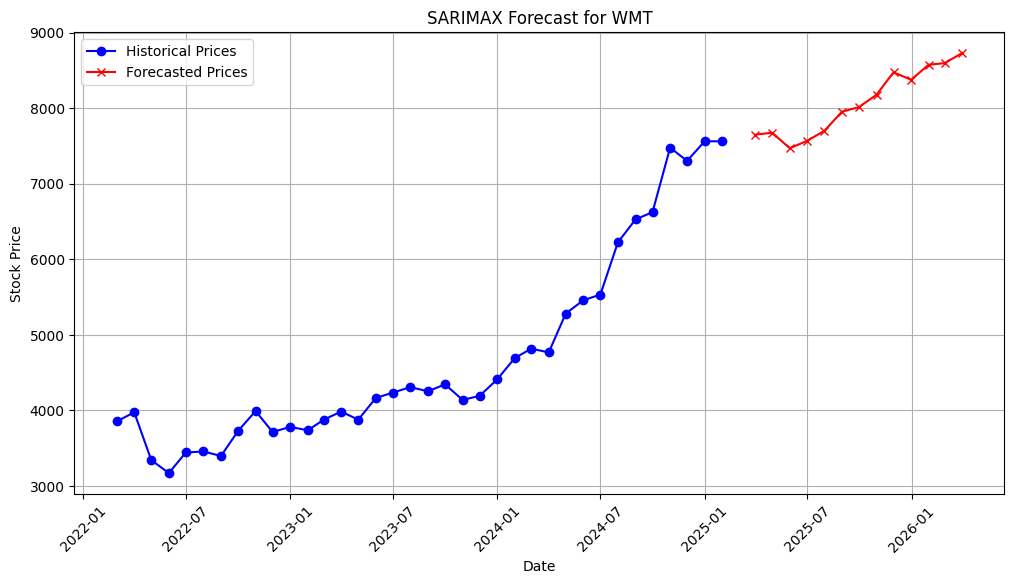


📊 Financial Metrics for WMT
-------------------------------------------------
Annualized Return (Historical): 0.2520
Annualized Return (Forecasted): 0.1412
Cumulative Return (Historical): 0.9623
Cumulative Return (Forecasted): 0.1412
Annualized Volatility (Historical): 0.9043
Annualized Volatility (Forecasted): 0.0621
Sharpe Ratio (Historical): 0.2012
Sharpe Ratio (Forecasted): 1.1468

🚀 Running SARIMAX for LT.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

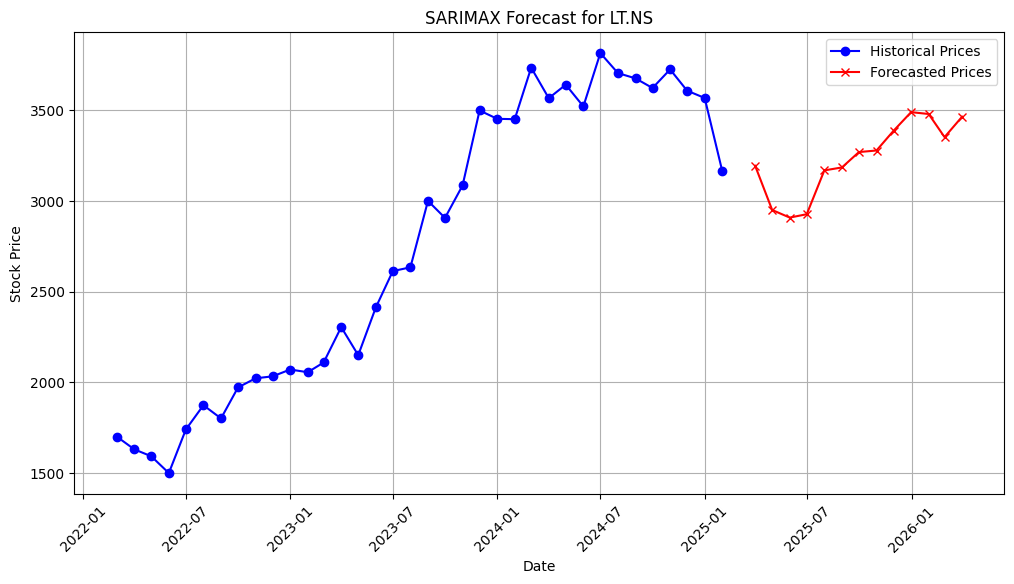


📊 Financial Metrics for LT.NS
-------------------------------------------------
Annualized Return (Historical): 0.2299
Annualized Return (Forecasted): 0.0848
Cumulative Return (Historical): 0.8603
Cumulative Return (Forecasted): 0.0848
Annualized Volatility (Historical): 1.0405
Annualized Volatility (Forecasted): 0.1380
Sharpe Ratio (Historical): 0.1536
Sharpe Ratio (Forecasted): 0.1073

🚀 Running SARIMAX for ABBV...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

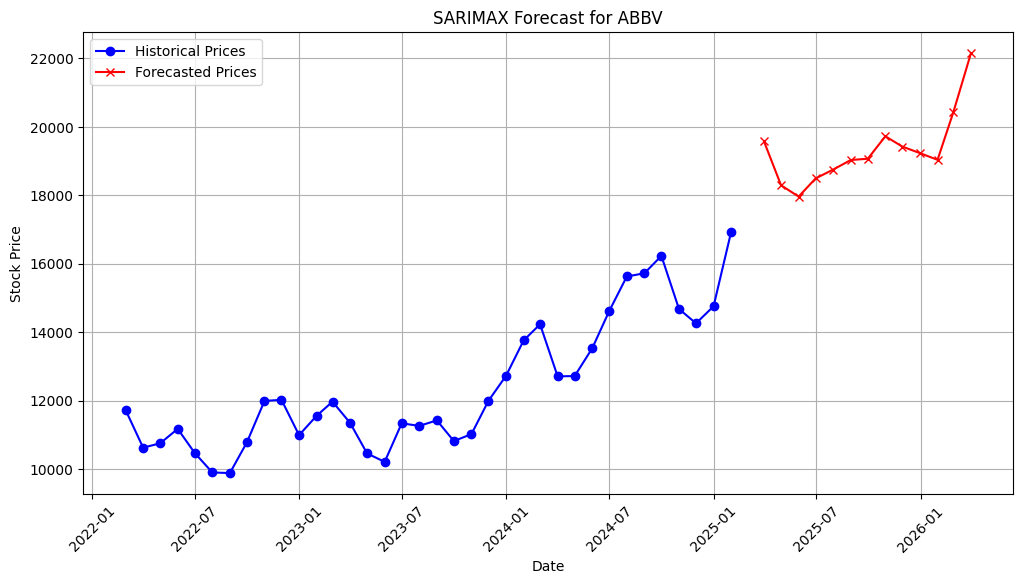


📊 Financial Metrics for ABBV
-------------------------------------------------
Annualized Return (Historical): 0.1301
Annualized Return (Forecasted): 0.1320
Cumulative Return (Historical): 0.4434
Cumulative Return (Forecasted): 0.1320
Annualized Volatility (Historical): 1.0503
Annualized Volatility (Forecasted): 0.1420
Sharpe Ratio (Historical): 0.0572
Sharpe Ratio (Forecasted): 0.4362

🚀 Running SARIMAX for POWERGRID.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/bas

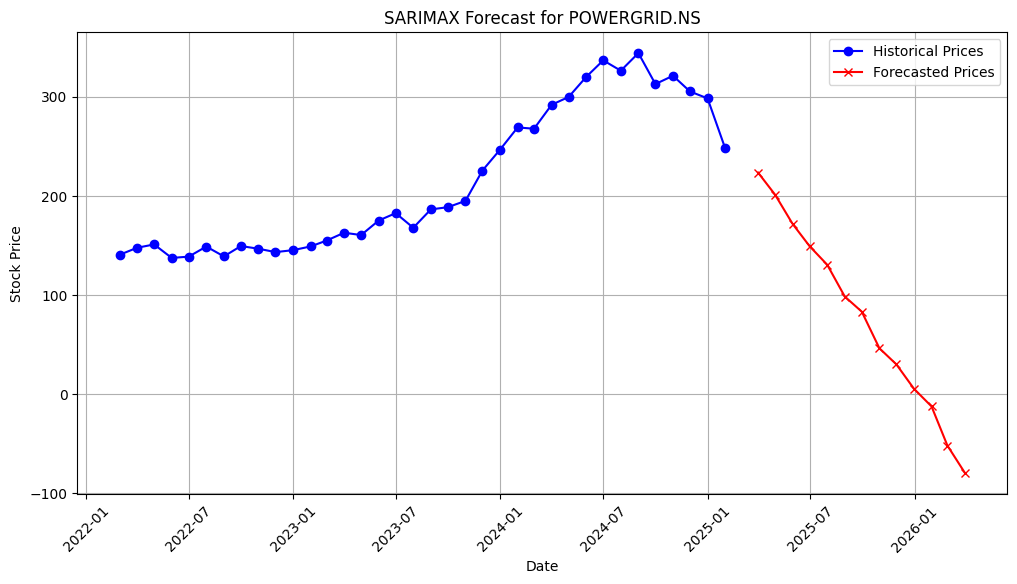


📊 Financial Metrics for POWERGRID.NS
-------------------------------------------------
Annualized Return (Historical): 0.2084
Annualized Return (Forecasted): -1.3560
Cumulative Return (Historical): 0.7647
Cumulative Return (Forecasted): -1.3560
Annualized Volatility (Historical): 1.0646
Annualized Volatility (Forecasted): 4.8876
Sharpe Ratio (Historical): 0.1300
Sharpe Ratio (Forecasted): -0.2918

🚀 Running SARIMAX for BPCL.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

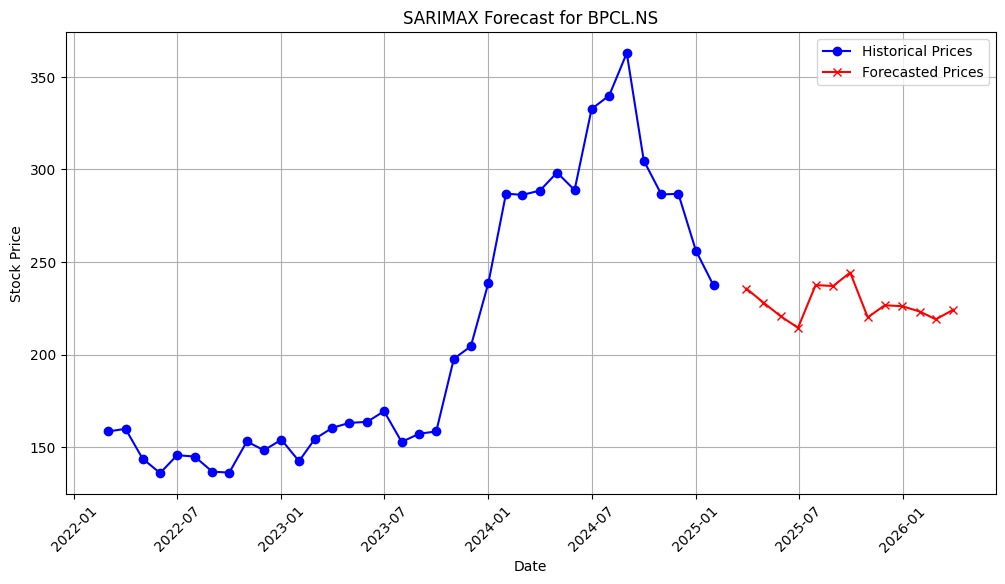


📊 Financial Metrics for BPCL.NS
-------------------------------------------------
Annualized Return (Historical): 0.1441
Annualized Return (Forecasted): -0.0484
Cumulative Return (Historical): 0.4978
Cumulative Return (Forecasted): -0.0484
Annualized Volatility (Historical): 1.4014
Annualized Volatility (Forecasted): 0.1718
Sharpe Ratio (Historical): 0.0529
Sharpe Ratio (Forecasted): -0.6888

🚀 Running SARIMAX for NFLX...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

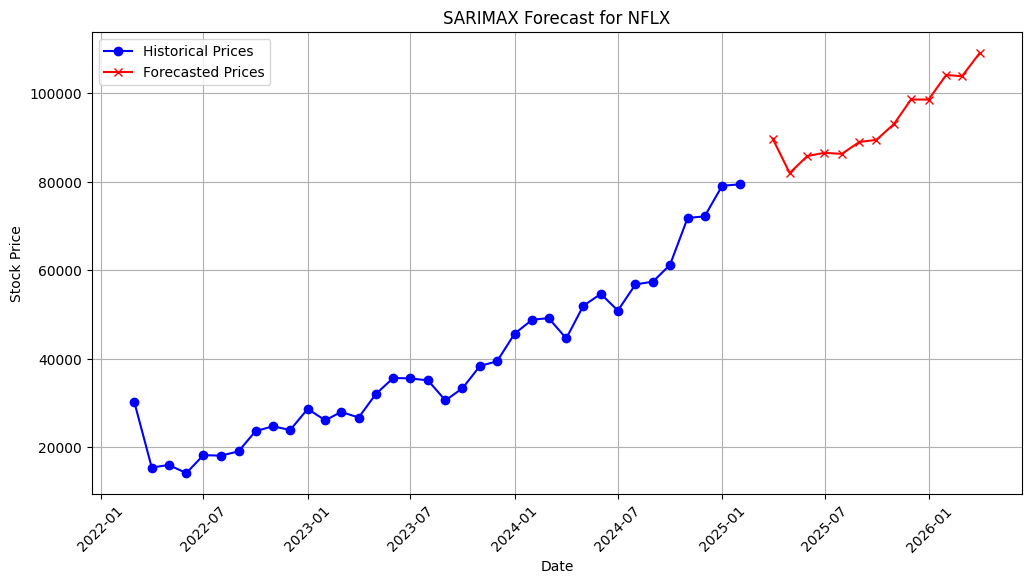


📊 Financial Metrics for NFLX
-------------------------------------------------
Annualized Return (Historical): 0.3782
Annualized Return (Forecasted): 0.2153
Cumulative Return (Historical): 1.6177
Cumulative Return (Forecasted): 0.2153
Annualized Volatility (Historical): 2.1721
Annualized Volatility (Forecasted): 0.1406
Sharpe Ratio (Historical): 0.1419
Sharpe Ratio (Forecasted): 1.0336

🚀 Running SARIMAX for JSWSTEEL.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

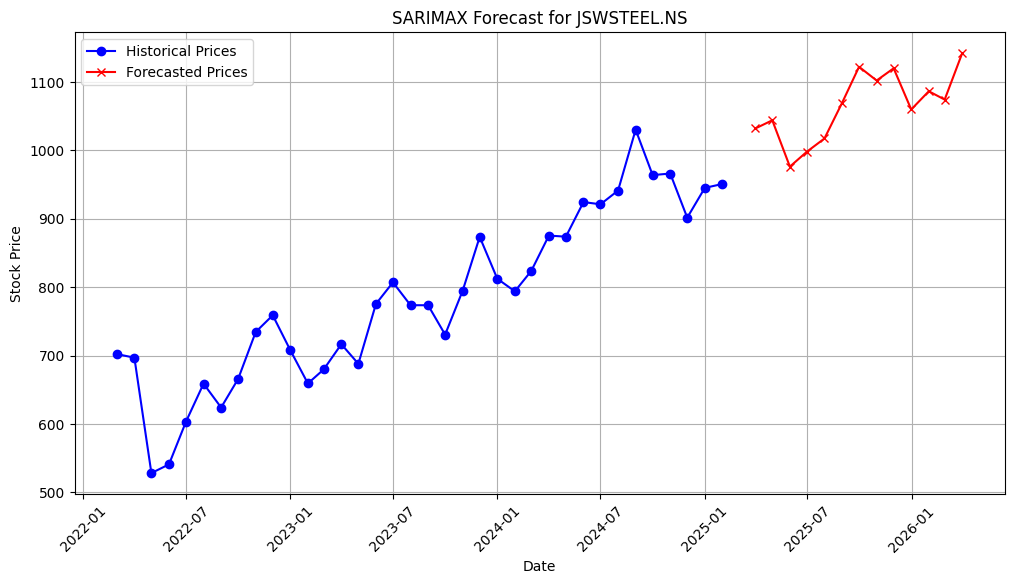


📊 Financial Metrics for JSWSTEEL.NS
-------------------------------------------------
Annualized Return (Historical): 0.1063
Annualized Return (Forecasted): 0.1068
Cumulative Return (Historical): 0.3539
Cumulative Return (Forecasted): 0.1068
Annualized Volatility (Historical): 1.1699
Annualized Volatility (Forecasted): 0.1380
Sharpe Ratio (Historical): 0.0310
Sharpe Ratio (Forecasted): 0.2666

🚀 Running SARIMAX for BTC-USD...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' i

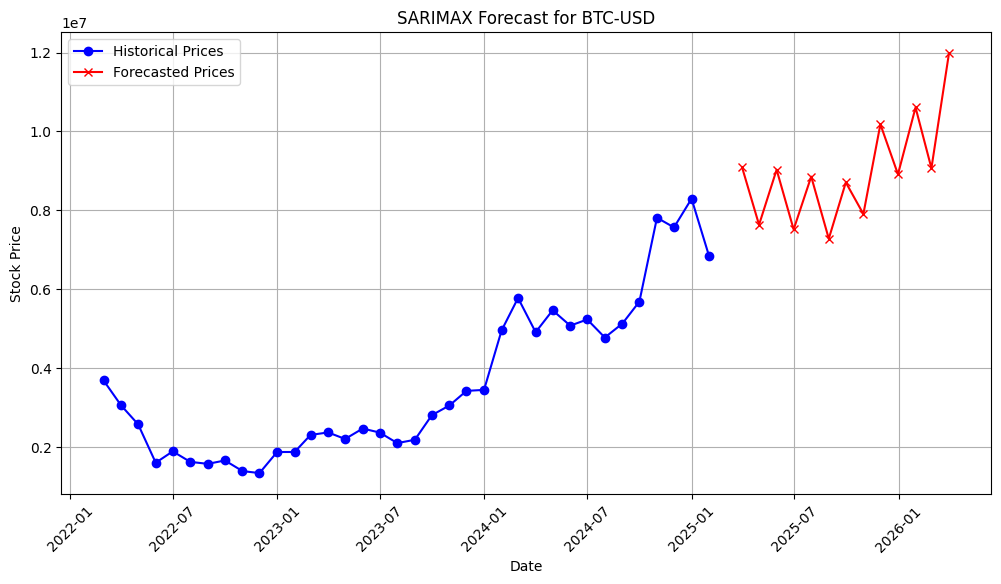


📊 Financial Metrics for BTC-USD
-------------------------------------------------
Annualized Return (Historical): 0.2282
Annualized Return (Forecasted): 0.3180
Cumulative Return (Historical): 0.8528
Cumulative Return (Forecasted): 0.3180
Annualized Volatility (Historical): 2.8041
Annualized Volatility (Forecasted): 0.6901
Sharpe Ratio (Historical): 0.0564
Sharpe Ratio (Forecasted): 0.3594

🚀 Running SARIMAX for TATASTEEL.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

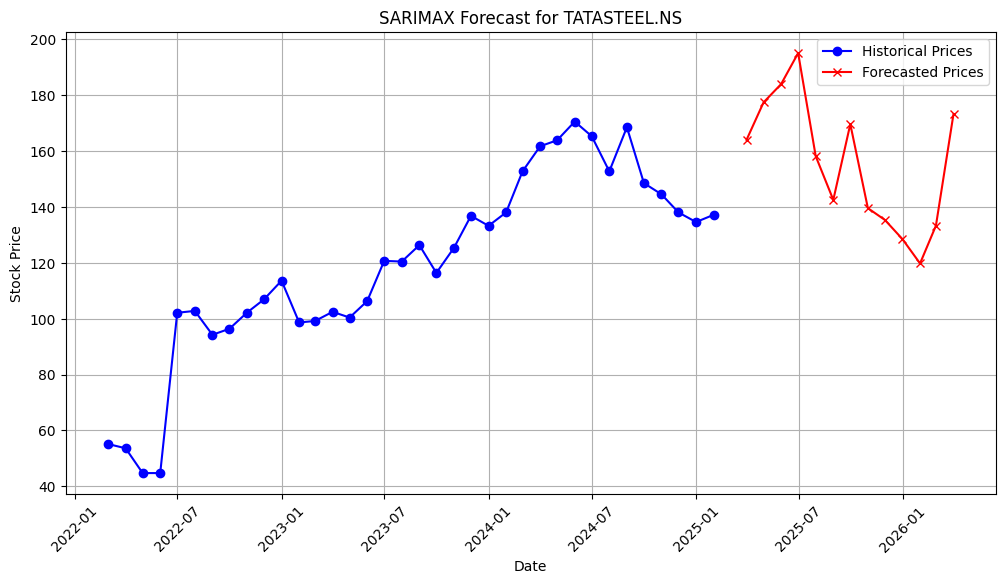


📊 Financial Metrics for TATASTEEL.NS
-------------------------------------------------
Annualized Return (Historical): 0.3549
Annualized Return (Forecasted): 0.0564
Cumulative Return (Historical): 1.4874
Cumulative Return (Forecasted): 0.0564
Annualized Volatility (Historical): 3.5978
Annualized Volatility (Forecasted): 0.5043
Sharpe Ratio (Historical): 0.0792
Sharpe Ratio (Forecasted): -0.0270

🚀 Running SARIMAX for COALINDIA.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

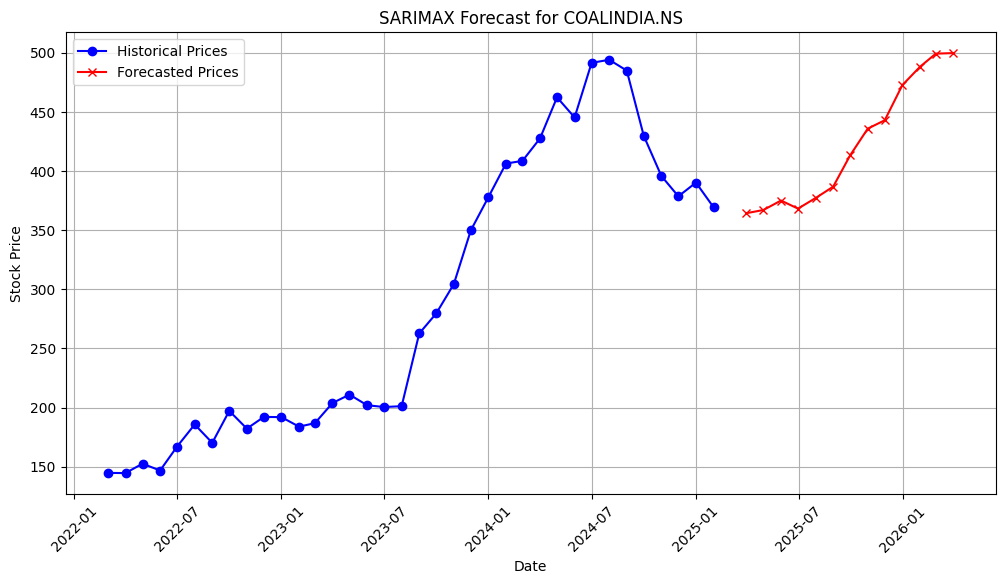


📊 Financial Metrics for COALINDIA.NS
-------------------------------------------------
Annualized Return (Historical): 0.3666
Annualized Return (Forecasted): 0.3716
Cumulative Return (Historical): 1.5522
Cumulative Return (Forecasted): 0.3716
Annualized Volatility (Historical): 1.3447
Annualized Volatility (Forecasted): 0.0899
Sharpe Ratio (Historical): 0.2206
Sharpe Ratio (Forecasted): 3.3567

🚀 Running SARIMAX for ICICIBANK.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

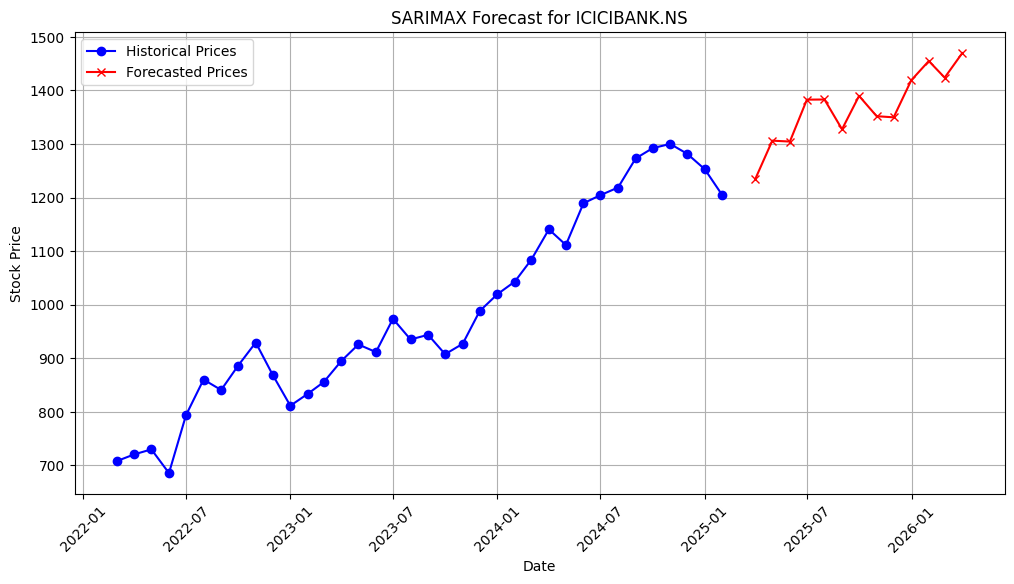


📊 Financial Metrics for ICICIBANK.NS
-------------------------------------------------
Annualized Return (Historical): 0.1936
Annualized Return (Forecasted): 0.1904
Cumulative Return (Historical): 0.7007
Cumulative Return (Forecasted): 0.1904
Annualized Volatility (Historical): 0.7447
Annualized Volatility (Forecasted): 0.1214
Sharpe Ratio (Historical): 0.1660
Sharpe Ratio (Forecasted): 0.9919

🚀 Running SARIMAX for JPM...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

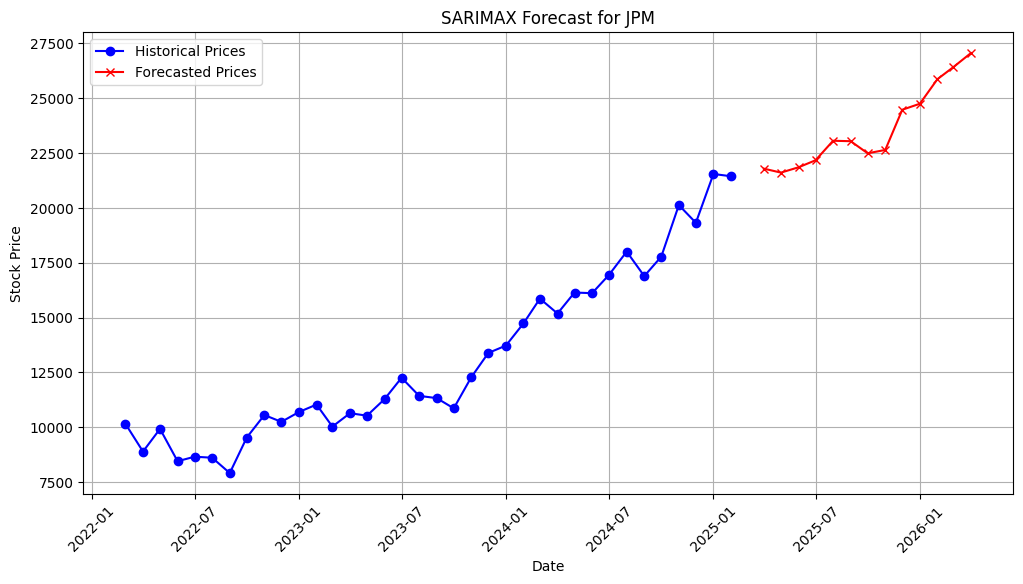


📊 Financial Metrics for JPM
-------------------------------------------------
Annualized Return (Historical): 0.2826
Annualized Return (Forecasted): 0.2417
Cumulative Return (Historical): 1.1099
Cumulative Return (Forecasted): 0.2417
Annualized Volatility (Historical): 1.2581
Annualized Volatility (Forecasted): 0.0950
Sharpe Ratio (Historical): 0.1690
Sharpe Ratio (Forecasted): 1.8076

🚀 Running SARIMAX for HCLTECH.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

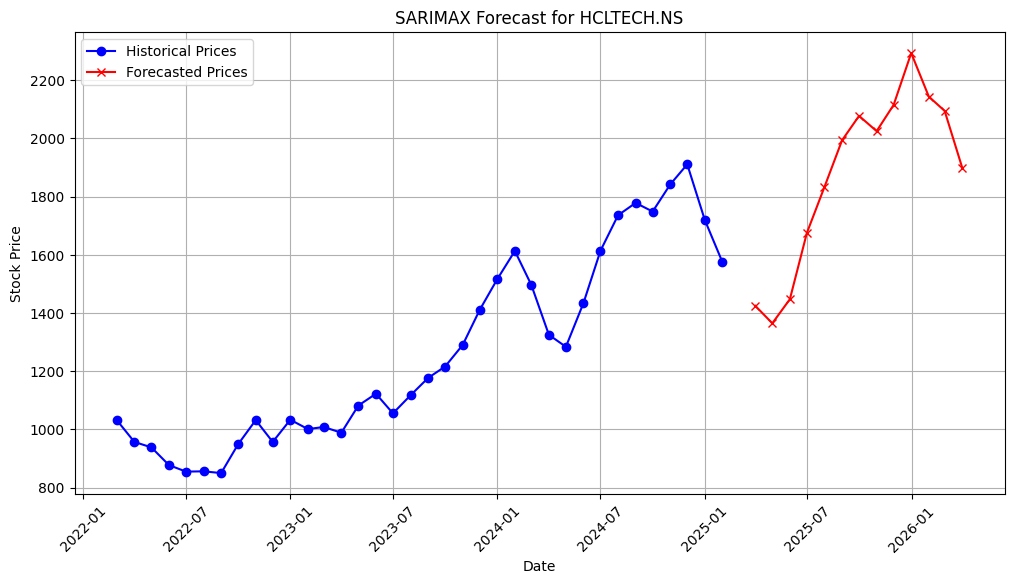


📊 Financial Metrics for HCLTECH.NS
-------------------------------------------------
Annualized Return (Historical): 0.1514
Annualized Return (Forecasted): 0.3328
Cumulative Return (Historical): 0.5264
Cumulative Return (Forecasted): 0.3328
Annualized Volatility (Historical): 1.0813
Annualized Volatility (Forecasted): 0.2624
Sharpe Ratio (Historical): 0.0753
Sharpe Ratio (Forecasted): 1.0018

🚀 Running SARIMAX for HEROMOTOCO.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

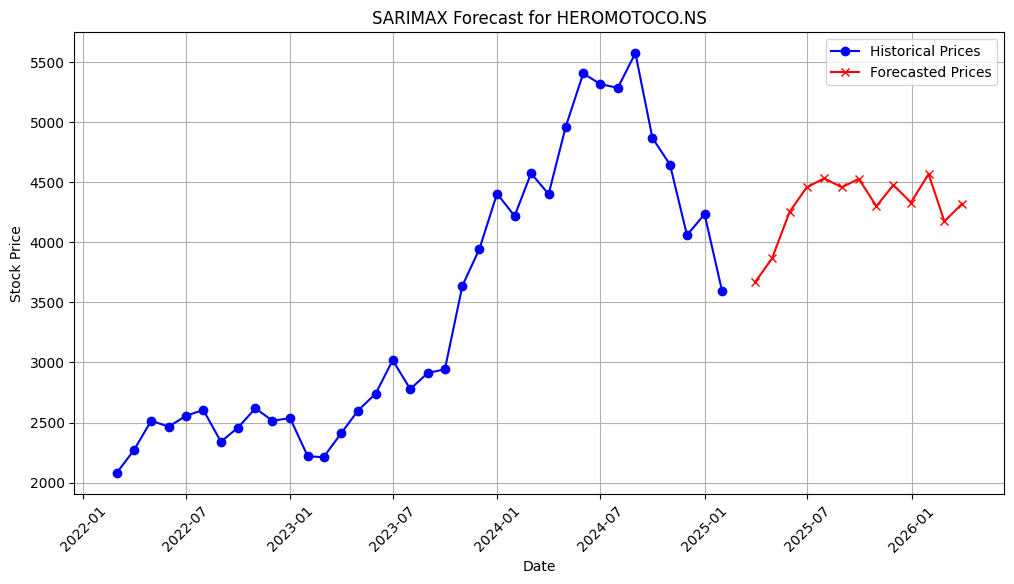


📊 Financial Metrics for HEROMOTOCO.NS
-------------------------------------------------
Annualized Return (Historical): 0.1996
Annualized Return (Forecasted): 0.1780
Cumulative Return (Historical): 0.7262
Cumulative Return (Forecasted): 0.1780
Annualized Volatility (Historical): 1.3687
Annualized Volatility (Forecasted): 0.1816
Sharpe Ratio (Historical): 0.0947
Sharpe Ratio (Forecasted): 0.5945

🚀 Running SARIMAX for V...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

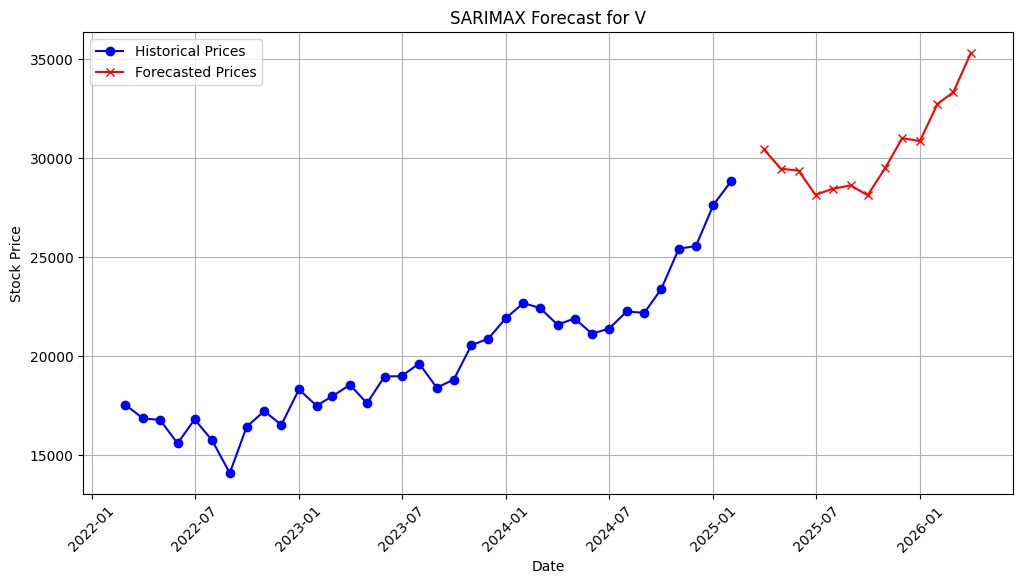


📊 Financial Metrics for V
-------------------------------------------------
Annualized Return (Historical): 0.1798
Annualized Return (Forecasted): 0.1597
Cumulative Return (Historical): 0.6420
Cumulative Return (Forecasted): 0.1597
Annualized Volatility (Historical): 0.9246
Annualized Volatility (Forecasted): 0.1225
Sharpe Ratio (Historical): 0.1187
Sharpe Ratio (Forecasted): 0.7326

🚀 Running SARIMAX for ADANIPORTS.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observation

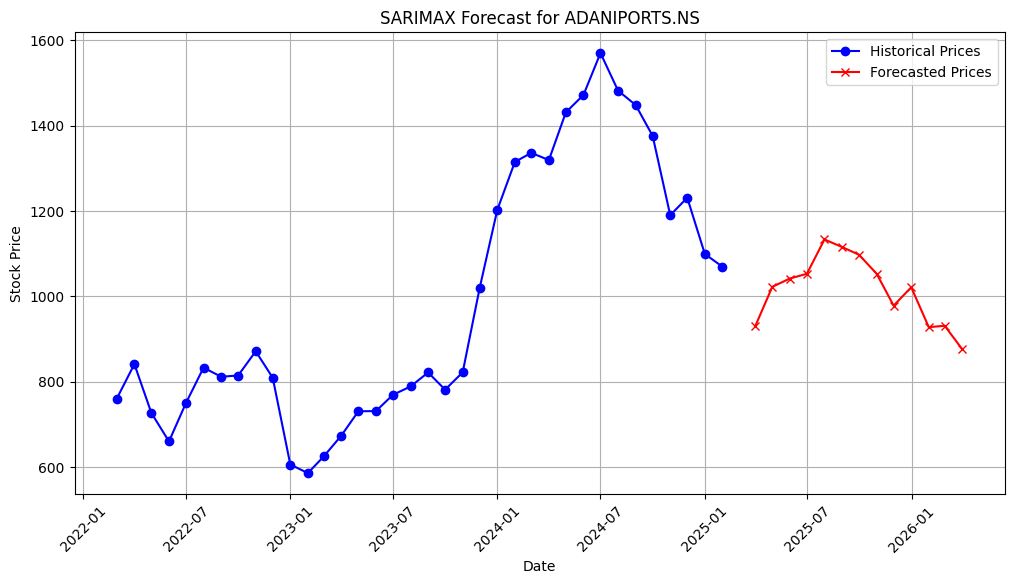


📊 Financial Metrics for ADANIPORTS.NS
-------------------------------------------------
Annualized Return (Historical): 0.1203
Annualized Return (Forecasted): -0.0583
Cumulative Return (Historical): 0.4062
Cumulative Return (Forecasted): -0.0583
Annualized Volatility (Historical): 1.5252
Annualized Volatility (Forecasted): 0.2007
Sharpe Ratio (Historical): 0.0330
Sharpe Ratio (Forecasted): -0.6394

🚀 Running SARIMAX for BRITANNIA.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

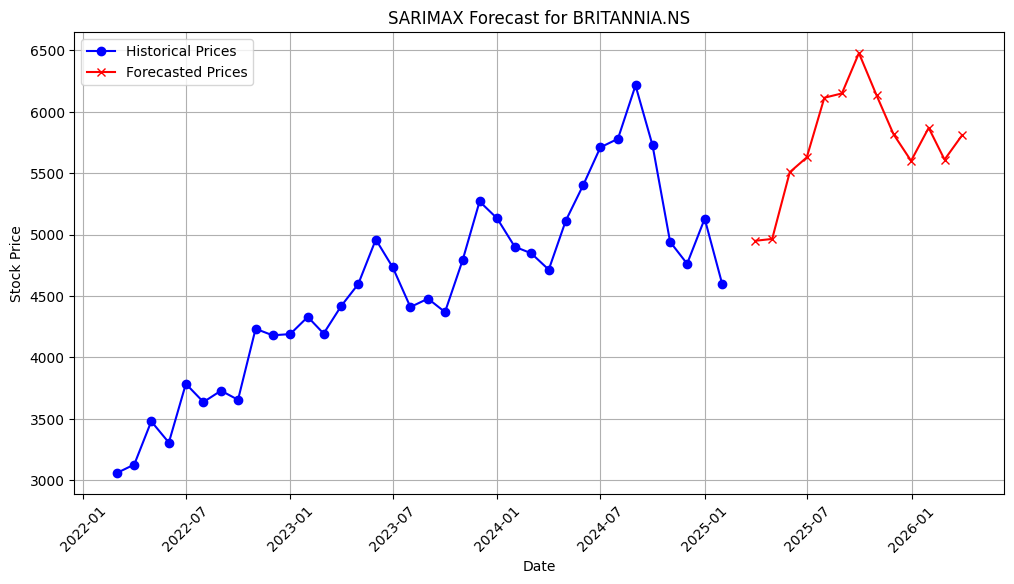


📊 Financial Metrics for BRITANNIA.NS
-------------------------------------------------
Annualized Return (Historical): 0.1453
Annualized Return (Forecasted): 0.1737
Cumulative Return (Historical): 0.5022
Cumulative Return (Forecasted): 0.1737
Annualized Volatility (Historical): 1.0995
Annualized Volatility (Forecasted): 0.1884
Sharpe Ratio (Historical): 0.0685
Sharpe Ratio (Forecasted): 0.5503

🚀 Running SARIMAX for ULTRACEMCO.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

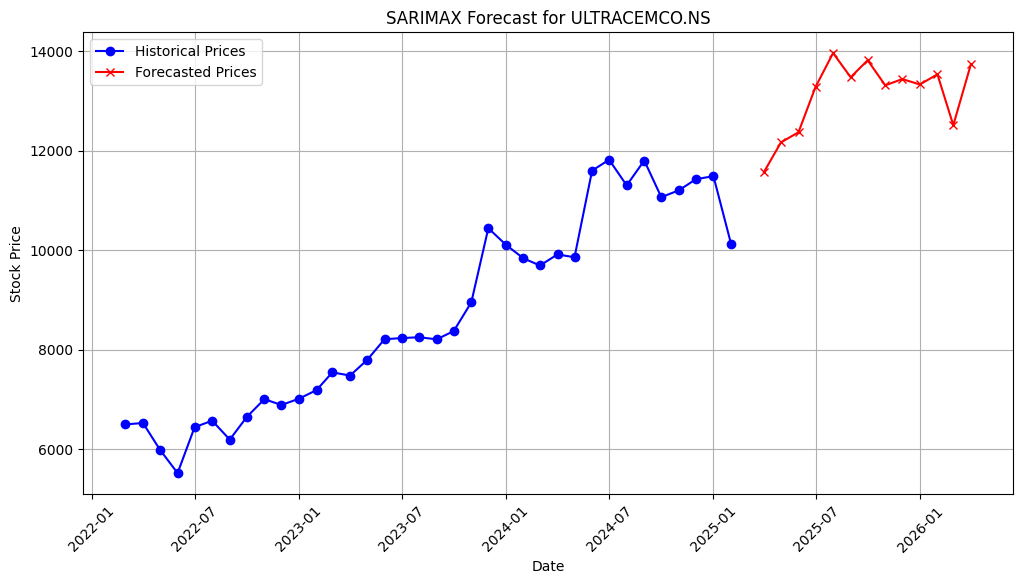


📊 Financial Metrics for ULTRACEMCO.NS
-------------------------------------------------
Annualized Return (Historical): 0.1596
Annualized Return (Forecasted): 0.1874
Cumulative Return (Historical): 0.5591
Cumulative Return (Forecasted): 0.1874
Annualized Volatility (Historical): 1.0301
Annualized Volatility (Forecasted): 0.1715
Sharpe Ratio (Historical): 0.0869
Sharpe Ratio (Forecasted): 0.6848

🚀 Running SARIMAX for SUNPHARMA.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

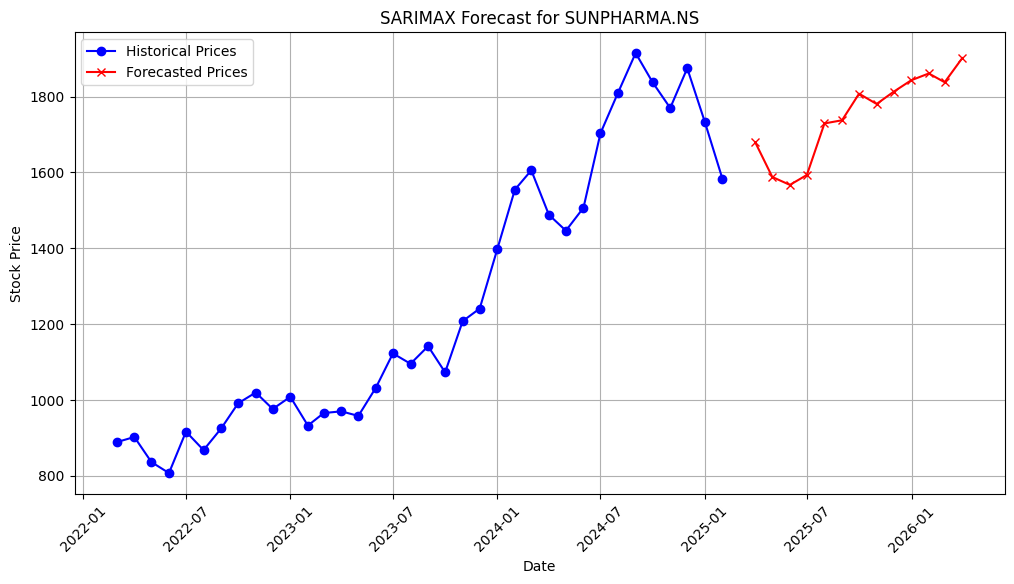


📊 Financial Metrics for SUNPHARMA.NS
-------------------------------------------------
Annualized Return (Historical): 0.2125
Annualized Return (Forecasted): 0.1325
Cumulative Return (Historical): 0.7825
Cumulative Return (Forecasted): 0.1325
Annualized Volatility (Historical): 1.0681
Annualized Volatility (Forecasted): 0.1199
Sharpe Ratio (Historical): 0.1334
Sharpe Ratio (Forecasted): 0.5209

🚀 Running SARIMAX for XOM...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_periods + 1, freq='M')[1:]


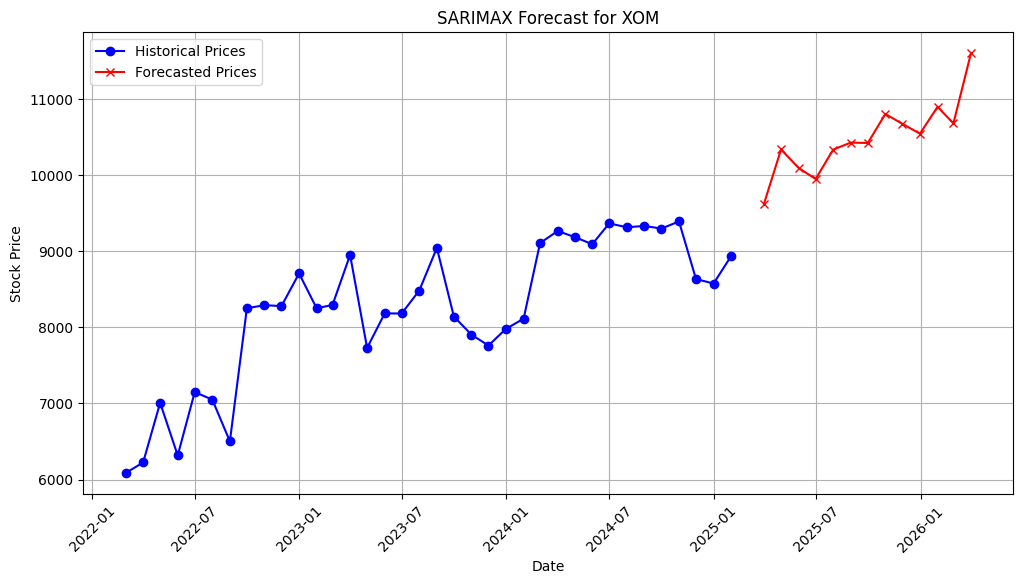


📊 Financial Metrics for XOM
-------------------------------------------------
Annualized Return (Historical): 0.1368
Annualized Return (Forecasted): 0.2056
Cumulative Return (Historical): 0.4689
Cumulative Return (Forecasted): 0.2056
Annualized Volatility (Historical): 1.1941
Annualized Volatility (Forecasted): 0.1289
Sharpe Ratio (Historical): 0.0559
Sharpe Ratio (Forecasted): 1.0513

🚀 Running SARIMAX for NTPC.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

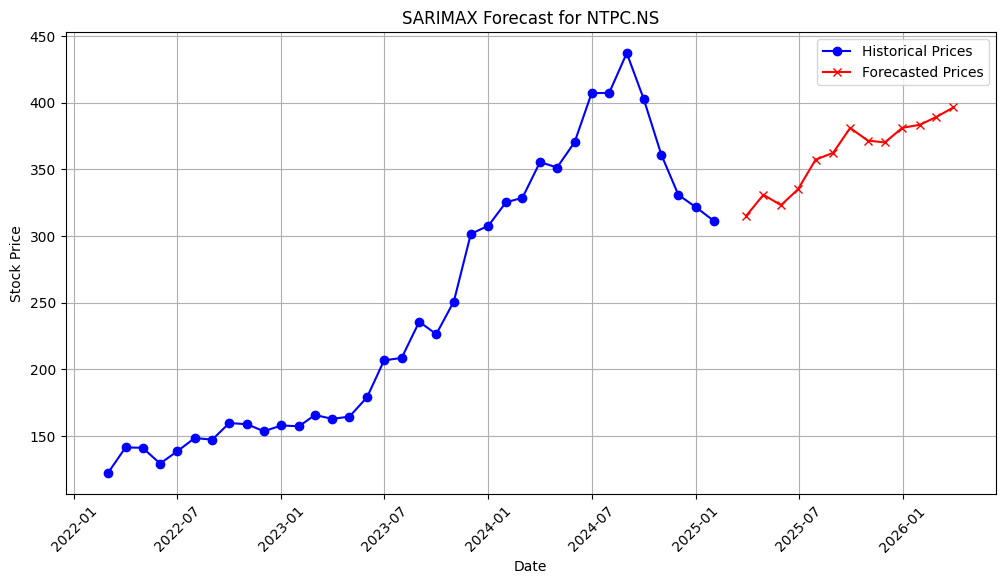


📊 Financial Metrics for NTPC.NS
-------------------------------------------------
Annualized Return (Historical): 0.3660
Annualized Return (Forecasted): 0.2570
Cumulative Return (Historical): 1.5491
Cumulative Return (Forecasted): 0.2570
Annualized Volatility (Historical): 1.1579
Annualized Volatility (Forecasted): 0.0996
Sharpe Ratio (Historical): 0.2557
Sharpe Ratio (Forecasted): 1.8761

🚀 Running SARIMAX for BRK-B...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_periods + 1, freq='M')[1:]


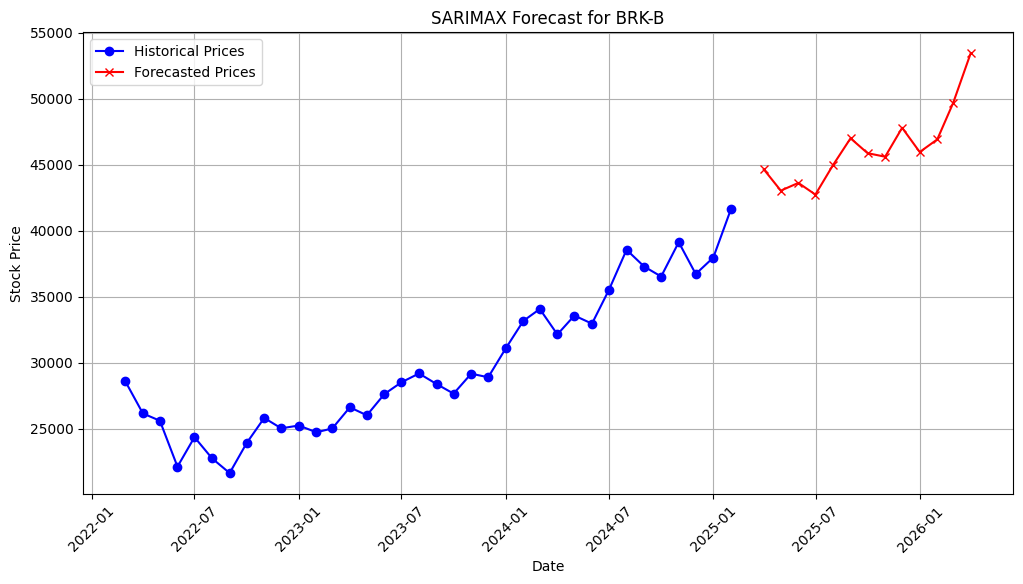


📊 Financial Metrics for BRK-B
-------------------------------------------------
Annualized Return (Historical): 0.1334
Annualized Return (Forecasted): 0.1973
Cumulative Return (Historical): 0.4560
Cumulative Return (Forecasted): 0.1973
Annualized Volatility (Historical): 0.9501
Annualized Volatility (Forecasted): 0.1391
Sharpe Ratio (Historical): 0.0667
Sharpe Ratio (Forecasted): 0.9151

🚀 Running SARIMAX for SBIN.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

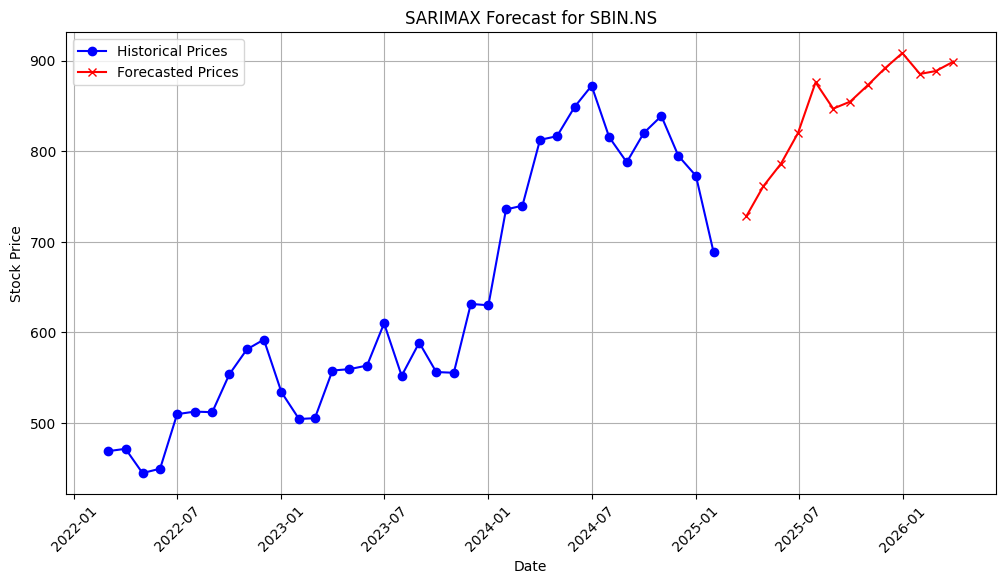


📊 Financial Metrics for SBIN.NS
-------------------------------------------------
Annualized Return (Historical): 0.1368
Annualized Return (Forecasted): 0.2342
Cumulative Return (Historical): 0.4692
Cumulative Return (Forecasted): 0.2342
Annualized Volatility (Historical): 1.0669
Annualized Volatility (Forecasted): 0.0989
Sharpe Ratio (Historical): 0.0626
Sharpe Ratio (Forecasted): 1.6608

🚀 Running SARIMAX for MARUTI.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

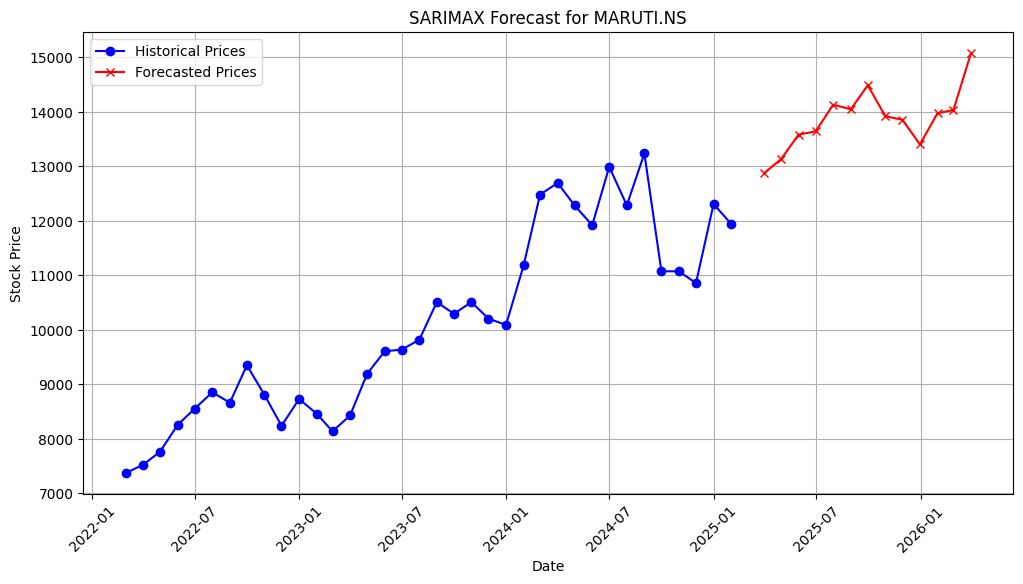


📊 Financial Metrics for MARUTI.NS
-------------------------------------------------
Annualized Return (Historical): 0.1746
Annualized Return (Forecasted): 0.1713
Cumulative Return (Historical): 0.6204
Cumulative Return (Forecasted): 0.1713
Annualized Volatility (Historical): 0.9760
Annualized Volatility (Forecasted): 0.1127
Sharpe Ratio (Historical): 0.1071
Sharpe Ratio (Forecasted): 0.8988

🚀 Running SARIMAX for CIPLA.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

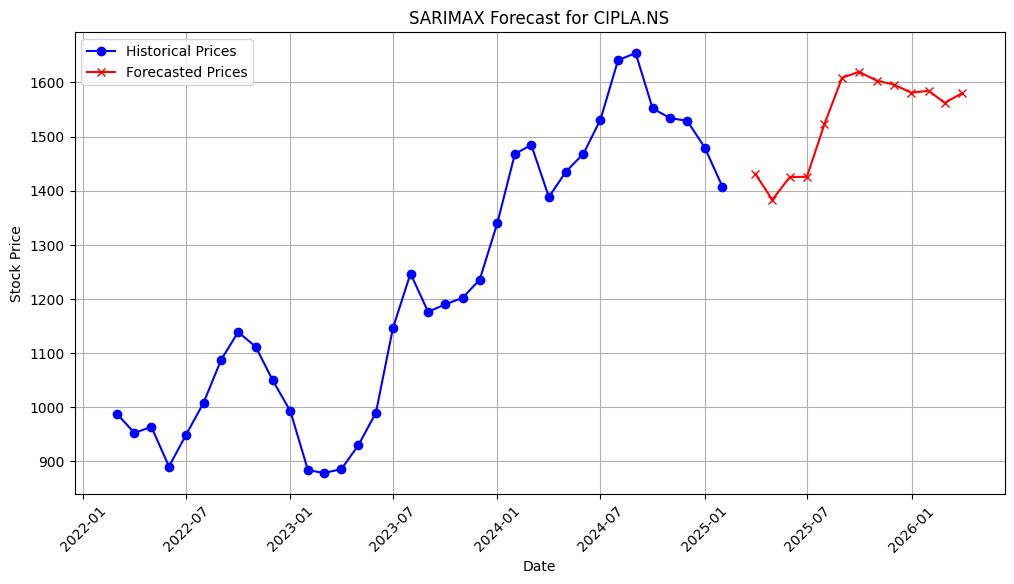


📊 Financial Metrics for CIPLA.NS
-------------------------------------------------
Annualized Return (Historical): 0.1251
Annualized Return (Forecasted): 0.1043
Cumulative Return (Historical): 0.4241
Cumulative Return (Forecasted): 0.1043
Annualized Volatility (Historical): 0.9348
Annualized Volatility (Forecasted): 0.1020
Sharpe Ratio (Historical): 0.0589
Sharpe Ratio (Forecasted): 0.3359

🚀 Running SARIMAX for SETFNIF50.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: C

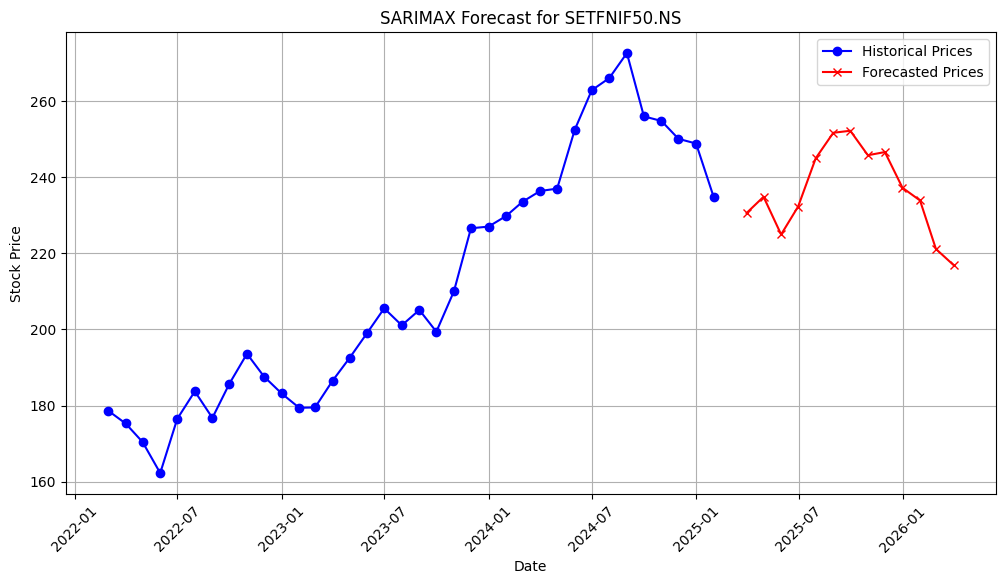


📊 Financial Metrics for SETFNIF50.NS
-------------------------------------------------
Annualized Return (Historical): 0.0953
Annualized Return (Forecasted): -0.0592
Cumulative Return (Historical): 0.3140
Cumulative Return (Forecasted): -0.0592
Annualized Volatility (Historical): 0.5966
Annualized Volatility (Forecasted): 0.1158
Sharpe Ratio (Historical): 0.0424
Sharpe Ratio (Forecasted): -1.1152

🚀 Running SARIMAX for IBM...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

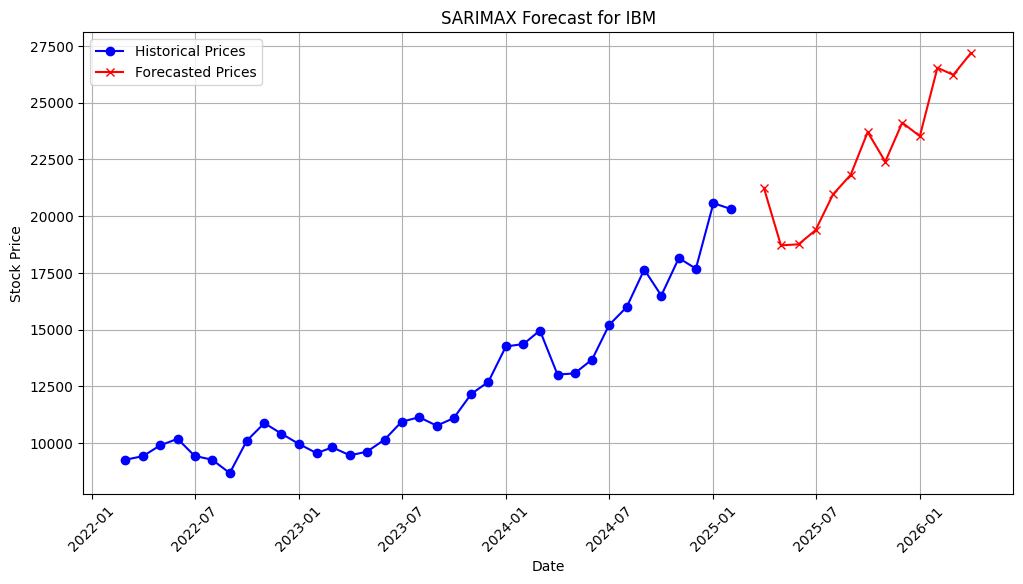


📊 Financial Metrics for IBM
-------------------------------------------------
Annualized Return (Historical): 0.2986
Annualized Return (Forecasted): 0.2796
Cumulative Return (Historical): 1.1900
Cumulative Return (Forecasted): 0.2796
Annualized Volatility (Historical): 1.0822
Annualized Volatility (Forecasted): 0.2385
Sharpe Ratio (Historical): 0.2113
Sharpe Ratio (Forecasted): 0.8789

🚀 Running SARIMAX for COCHINSHIP.BO...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

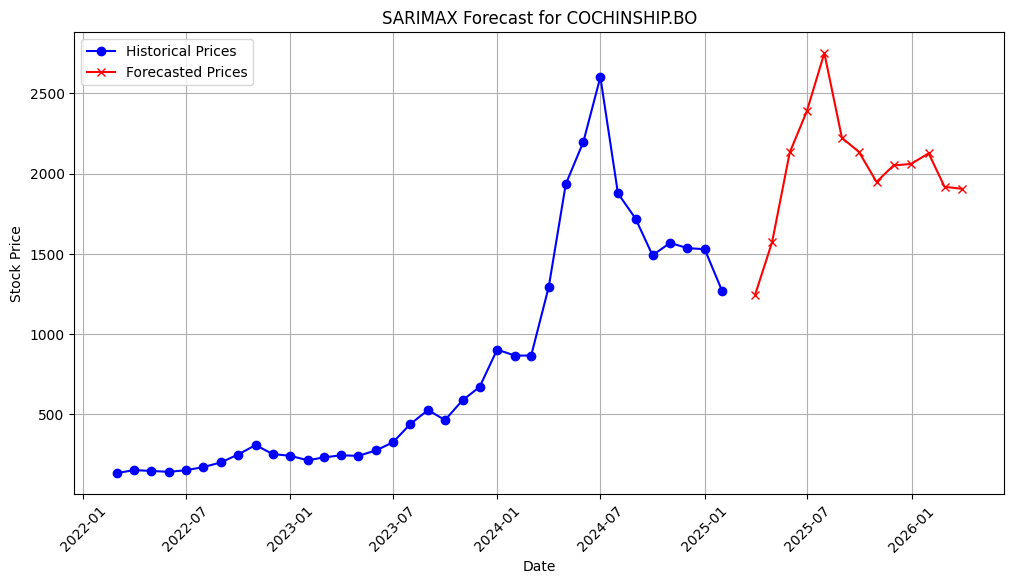


📊 Financial Metrics for COCHINSHIP.BO
-------------------------------------------------
Annualized Return (Historical): 1.1194
Annualized Return (Forecasted): 0.5295
Cumulative Return (Historical): 8.5199
Cumulative Return (Forecasted): 0.5295
Annualized Volatility (Historical): 2.9062
Annualized Volatility (Forecasted): 0.5392
Sharpe Ratio (Historical): 0.3611
Sharpe Ratio (Forecasted): 0.8521

🚀 Running SARIMAX for MA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_periods + 1, freq='M')[1:]


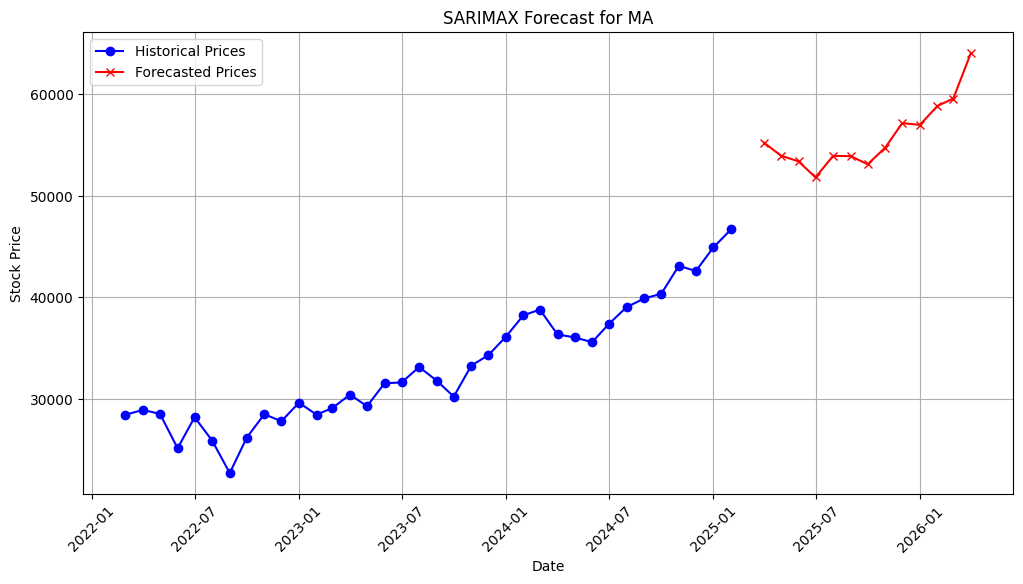


📊 Financial Metrics for MA
-------------------------------------------------
Annualized Return (Historical): 0.1797
Annualized Return (Forecasted): 0.1596
Cumulative Return (Historical): 0.6416
Cumulative Return (Forecasted): 0.1596
Annualized Volatility (Historical): 0.9920
Annualized Volatility (Forecasted): 0.1107
Sharpe Ratio (Historical): 0.1105
Sharpe Ratio (Forecasted): 0.8098

🚀 Running SARIMAX for ONGC.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

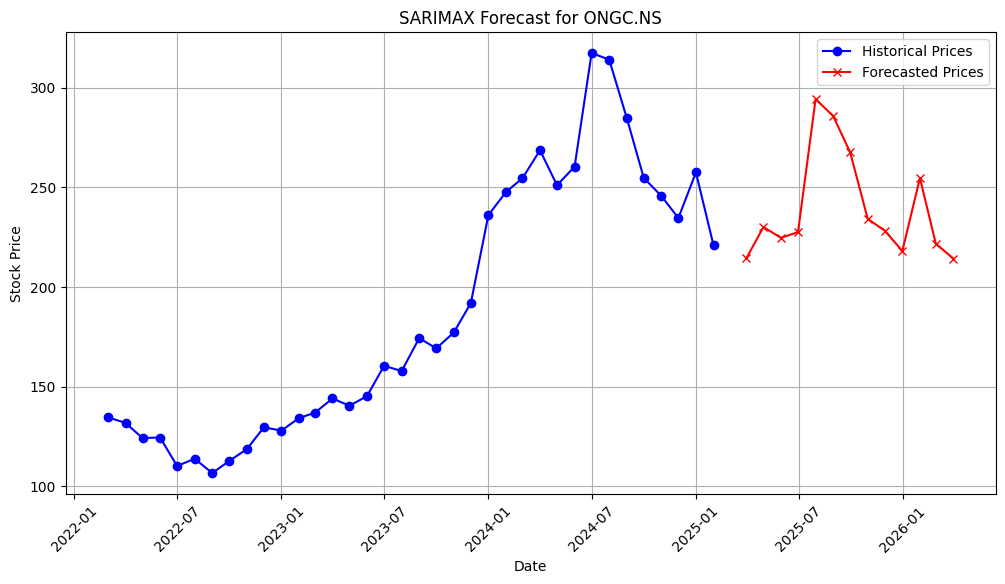


📊 Financial Metrics for ONGC.NS
-------------------------------------------------
Annualized Return (Historical): 0.1795
Annualized Return (Forecasted): -0.0009
Cumulative Return (Historical): 0.6410
Cumulative Return (Forecasted): -0.0009
Annualized Volatility (Historical): 1.3098
Annualized Volatility (Forecasted): 0.4189
Sharpe Ratio (Historical): 0.0836
Sharpe Ratio (Forecasted): -0.1692

🚀 Running SARIMAX for GRASIM.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

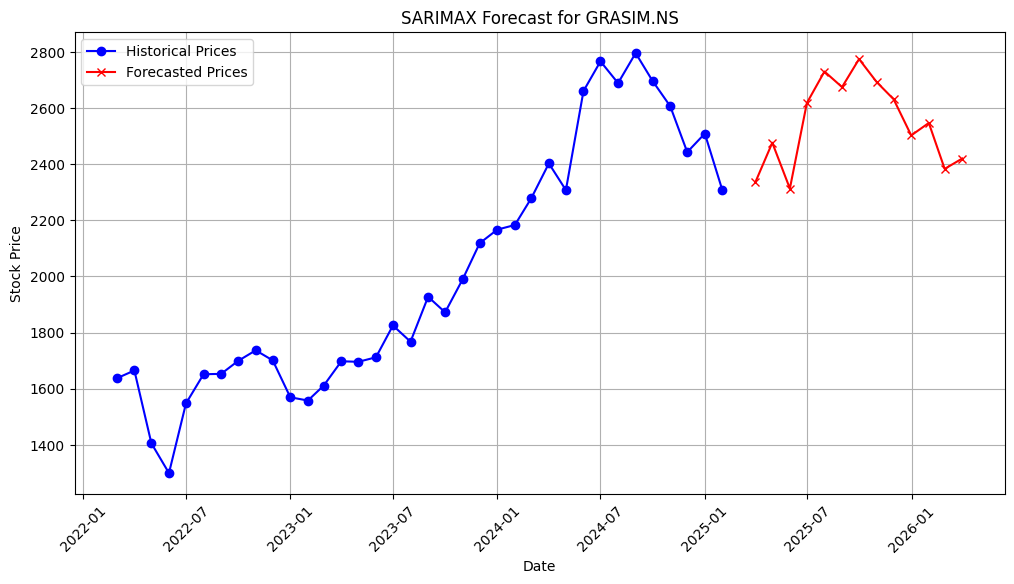


📊 Financial Metrics for GRASIM.NS
-------------------------------------------------
Annualized Return (Historical): 0.1211
Annualized Return (Forecasted): 0.0365
Cumulative Return (Historical): 0.4091
Cumulative Return (Forecasted): 0.0365
Annualized Volatility (Historical): 1.0493
Annualized Volatility (Forecasted): 0.2016
Sharpe Ratio (Historical): 0.0487
Sharpe Ratio (Forecasted): -0.1664

🚀 Running SARIMAX for ITC.NS...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-4-49de9d81dec0>:19: FutureWarning: 'M' is deprecated and will be r

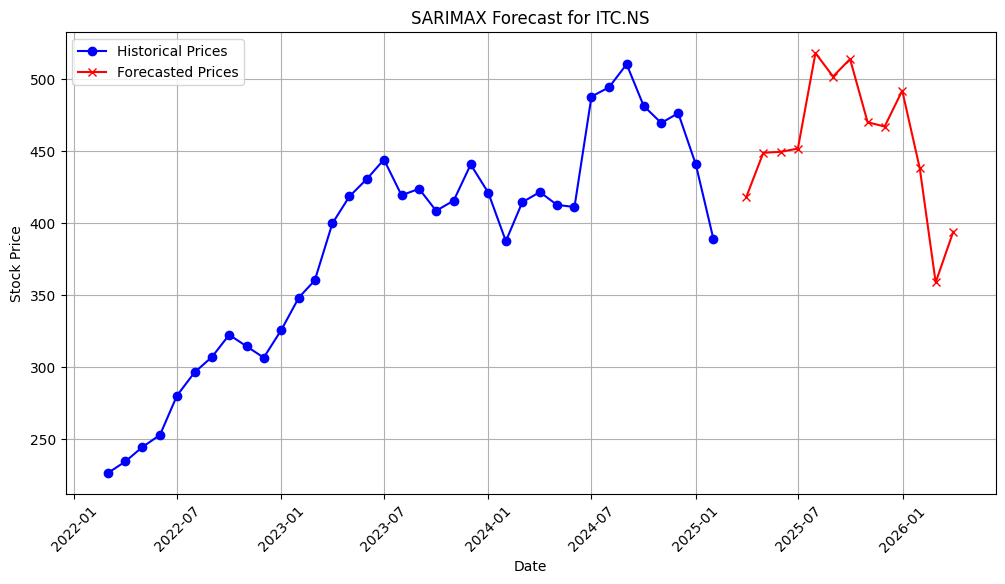


📊 Financial Metrics for ITC.NS
-------------------------------------------------
Annualized Return (Historical): 0.1976
Annualized Return (Forecasted): -0.0576
Cumulative Return (Historical): 0.7177
Cumulative Return (Forecasted): -0.0576
Annualized Volatility (Historical): 0.9492
Annualized Volatility (Forecasted): 0.3185
Sharpe Ratio (Historical): 0.1344
Sharpe Ratio (Forecasted): -0.4006


In [ ]:
results = {}

for stock_name, df in stock_data.items():
    print(f"\n🚀 Running SARIMAX for {stock_name}...")

    # Run SARIMAX Forecast
    df_forecast = sarimax_forecast(stock_name, df)

    # Compute Financial Metrics
    metrics = compute_metrics(stock_name, df, df_forecast)

    # Store results
    results[stock_name] = {
        "forecast": df_forecast,
        "metrics": metrics
    }


In [ ]:
import numpy as np
import pandas as pd

stock_names = list(results.keys())

# Extract forecasted annualized returns and volatilities
expected_returns = np.array([results[stock]["metrics"]["Annualized Return (Forecast)"] for stock in stock_names])
volatilities = np.array([results[stock]["metrics"]["Annualized Volatility (Forecast)"] for stock in stock_names])

# Prepare a DataFrame for historical daily returns
historical_returns_df = pd.DataFrame({stock: results[stock]["forecast"]["Daily Return"] for stock in stock_names})

# Compute the covariance matrix (based on historical daily returns)
covariance_matrix = historical_returns_df.cov()

print("\n Expected Annualized Returns:", expected_returns)
print("\n Expected Annualized Volatilities:", volatilities)
print("\n Correlation Matrix:")
#print(covariance_matrix)



 Expected Annualized Returns: [ 3.16545905e-01 -4.44966333e-02  2.05481119e-01  2.93622177e-01
  2.52895052e-01  1.67369359e-01  2.58817545e-01  2.42913277e-01
  1.41237722e-01  8.48050074e-02  1.31962507e-01 -1.35598038e+00
 -4.83599200e-02  2.15323966e-01  1.06793461e-01  3.18020188e-01
  5.63655425e-02  3.71637568e-01  1.90440520e-01  2.41719528e-01
  3.32837457e-01  1.77977431e-01  1.59728108e-01 -5.83276538e-02
  1.73678030e-01  1.87425435e-01  1.32473497e-01  2.05550103e-01
  2.56950680e-01  1.97313882e-01  2.34236820e-01  1.71296457e-01
  1.04262724e-01 -5.91815048e-02  2.79606476e-01  5.29469578e-01
  1.59602205e-01 -8.72942824e-04  3.64512102e-02 -5.76072118e-02]

 Expected Annualized Volatilities: [0.13820489 0.10965308 0.19060553 0.10862175 0.10466418 0.07398331
 0.12766054 0.1191908  0.06211662 0.13795247 0.14204768 4.88755372
 0.17182596 0.14060058 0.13800874 0.69011153 0.50432515 0.08986219
 0.12143012 0.09499873 0.262374   0.1816302  0.12247528 0.20070141
 0.18839794 0.

In [ ]:
import numpy as np
import pandas as pd

stock_names = list(results.keys())

# Extract forecasted annualized returns and volatilities into dictionaries
expected_returns = {stock: results[stock]["metrics"]["Annualized Return (Forecast)"] for stock in stock_names}
volatilities = {stock: results[stock]["metrics"]["Annualized Volatility (Forecast)"] for stock in stock_names}

# Prepare a DataFrame for historical daily returns
historical_returns_df = pd.DataFrame({stock: results[stock]["forecast"]["Daily Return"] for stock in stock_names})

# Compute the covariance matrix (based on historical daily returns)
covariance_matrix = historical_returns_df.cov()

print("\n✅ Expected Annualized Returns:")
for stock, ret in expected_returns.items():
    print(f"{stock}: {ret:.4f}")

print("\n✅ Expected Annualized Volatilities:")
for stock, vol in volatilities.items():
    print(f"{stock}: {vol:.4f}")

# print("\n✅ Covariance Matrix:")
# print(covariance_matrix)



✅ Expected Annualized Returns:
GC=F: 0.3165
NIFTYBEES.NS: -0.0445
ORCL: 0.2055
NVDA: 0.2936
META: 0.2529
BHARTIARTL.NS: 0.1674
GE: 0.2588
AAPL: 0.2429
WMT: 0.1412
LT.NS: 0.0848
ABBV: 0.1320
POWERGRID.NS: -1.3560
BPCL.NS: -0.0484
NFLX: 0.2153
JSWSTEEL.NS: 0.1068
BTC-USD: 0.3180
TATASTEEL.NS: 0.0564
COALINDIA.NS: 0.3716
ICICIBANK.NS: 0.1904
JPM: 0.2417
HCLTECH.NS: 0.3328
HEROMOTOCO.NS: 0.1780
V: 0.1597
ADANIPORTS.NS: -0.0583
BRITANNIA.NS: 0.1737
ULTRACEMCO.NS: 0.1874
SUNPHARMA.NS: 0.1325
XOM: 0.2056
NTPC.NS: 0.2570
BRK-B: 0.1973
SBIN.NS: 0.2342
MARUTI.NS: 0.1713
CIPLA.NS: 0.1043
SETFNIF50.NS: -0.0592
IBM: 0.2796
COCHINSHIP.BO: 0.5295
MA: 0.1596
ONGC.NS: -0.0009
GRASIM.NS: 0.0365
ITC.NS: -0.0576

✅ Expected Annualized Volatilities:
GC=F: 0.1382
NIFTYBEES.NS: 0.1097
ORCL: 0.1906
NVDA: 0.1086
META: 0.1047
BHARTIARTL.NS: 0.0740
GE: 0.1277
AAPL: 0.1192
WMT: 0.0621
LT.NS: 0.1380
ABBV: 0.1420
POWERGRID.NS: 4.8876
BPCL.NS: 0.1718
NFLX: 0.1406
JSWSTEEL.NS: 0.1380
BTC-USD: 0.6901
TATASTEEL.NS: 0.

In [ ]:
outliers = []
stock_names = [stock for stock in stock_names if stock not in outliers]

# Remove outliers from expected_returns and volatilities
expected_returns = {stock: ret for stock, ret in expected_returns.items() if stock not in outliers}
volatilities = {stock: vol for stock, vol in volatilities.items() if stock not in outliers}

# Remove outliers from historical_returns_df
historical_returns_df = historical_returns_df.drop(columns=outliers)

# Recompute covariance matrix
covariance_matrix = historical_returns_df.cov()

In [ ]:
expected_returns = {stock: ret for stock, ret in expected_returns.items() if stock not in outliers}

In [ ]:
len(expected_returns)

40


📊 Max Sharpe Ratio Portfolio:
  Expected Return: 0.1872
  Volatility (Risk): 0.0180
  Sharpe Ratio: 6.7511
  Weights (%):
    GC=F: 4.71%
    NIFTYBEES.NS: 0.64%
    ORCL: 1.11%
    NVDA: 5.33%
    META: 2.03%
    BHARTIARTL.NS: 0.03%
    GE: 2.64%
    AAPL: 3.90%
    WMT: 4.07%
    LT.NS: 2.39%
    ABBV: 3.69%
    POWERGRID.NS: 0.50%
    BPCL.NS: 1.26%
    NFLX: 1.43%
    JSWSTEEL.NS: 5.08%
    BTC-USD: 0.13%
    TATASTEEL.NS: 1.07%
    COALINDIA.NS: 5.32%
    ICICIBANK.NS: 4.85%
    JPM: 3.19%
    HCLTECH.NS: 3.77%
    HEROMOTOCO.NS: 0.24%
    V: 4.88%
    ADANIPORTS.NS: 3.38%
    BRITANNIA.NS: 0.46%
    ULTRACEMCO.NS: 2.63%
    SUNPHARMA.NS: 2.09%
    XOM: 1.69%
    NTPC.NS: 0.00%
    BRK-B: 3.09%
    SBIN.NS: 2.66%
    MARUTI.NS: 4.47%
    CIPLA.NS: 3.05%
    SETFNIF50.NS: 0.73%
    IBM: 1.95%
    COCHINSHIP.BO: 4.14%
    MA: 1.38%
    ONGC.NS: 2.83%
    GRASIM.NS: 0.33%
    ITC.NS: 2.85%

📊 Min Volatility Portfolio:
  Expected Return: 0.1783
  Volatility (Risk): 0.0168
  Sharpe R

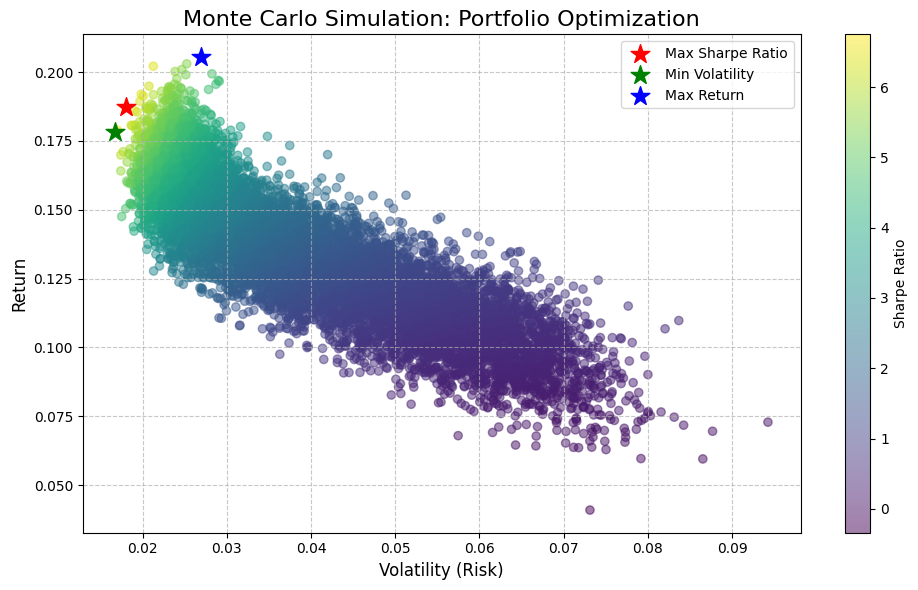

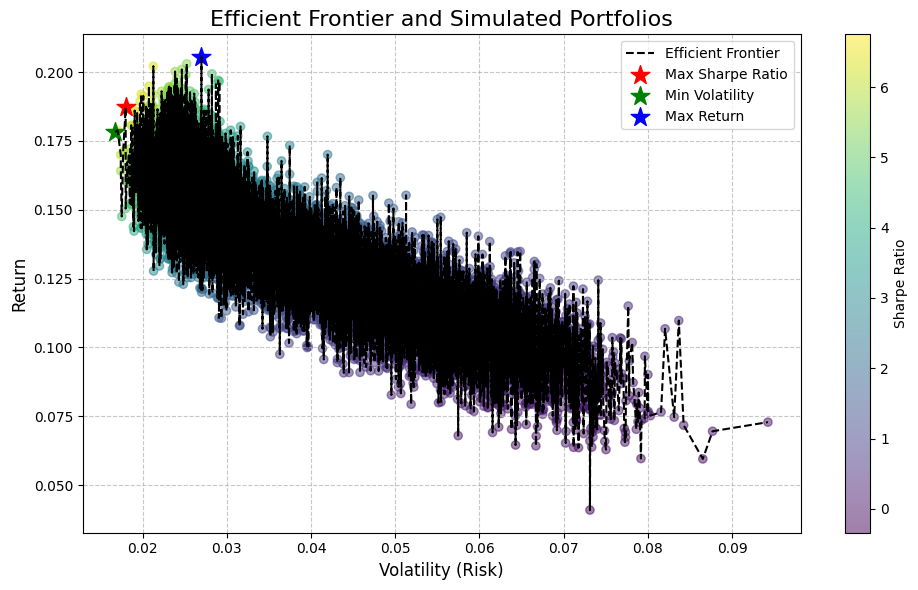

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def monte_carlo_simulation(expected_returns, covariance_matrix, num_portfolios=10000, risk_free_rate=0.0658):
    """
    Perform Monte Carlo simulation for portfolio optimization.

    Parameters:
    - expected_returns (dict): Forecasted annualized returns for each stock.
    - covariance_matrix (pd.DataFrame): Covariance matrix of stock returns.
    - num_portfolios (int): Number of random portfolios to simulate.
    - risk_free_rate (float): Risk-free rate for Sharpe ratio calculation.

    Returns:
    - portfolio_results (dict): Dictionary containing portfolio metrics (returns, volatility, Sharpe ratios, weights).
    """

    np.random.seed(42)  # Ensures reproducibility

    stock_names = list(expected_returns.keys())
    num_stocks = len(stock_names)

    # Convert dictionary values to arrays
    expected_returns_array = np.array(list(expected_returns.values()))
    covariance_matrix_array = covariance_matrix.to_numpy()

    # Arrays to store results
    all_weights = []
    all_returns = []
    all_volatilities = []
    all_sharpe_ratios = []

    # Monte Carlo Simulation
    for _ in range(num_portfolios):
        # Generate random weights
        weights = np.random.random(num_stocks)
        weights /= np.sum(weights)  # Normalize weights to sum to 1

        # Portfolio return
        portfolio_return = np.dot(weights, expected_returns_array)

        # Portfolio volatility
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix_array, weights)))

        # Sharpe ratio
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

        # Store results
        all_weights.append(weights)
        all_returns.append(portfolio_return)
        all_volatilities.append(portfolio_volatility)
        all_sharpe_ratios.append(sharpe_ratio)

    # Convert results to numpy arrays
    all_returns = np.array(all_returns)
    all_volatilities = np.array(all_volatilities)
    all_sharpe_ratios = np.array(all_sharpe_ratios)
    all_weights = np.array(all_weights)

    # Store results in a dictionary
    portfolio_results = {
        "returns": all_returns,
        "volatilities": all_volatilities,
        "sharpe_ratios": all_sharpe_ratios,
        "weights": all_weights,
        "stock_names": stock_names
    }

    return portfolio_results

# Run Monte Carlo Simulation
risk_free_rate = 0.0658  # Updated risk-free rate (6.58%)
portfolio_results = monte_carlo_simulation(expected_returns, covariance_matrix, risk_free_rate=risk_free_rate)

# ✅ Extract best portfolios
max_sharpe_idx = np.argmax(portfolio_results["sharpe_ratios"])
min_risk_idx = np.argmin(portfolio_results["volatilities"])
max_return_idx = np.argmax(portfolio_results["returns"])

# Best portfolios
best_portfolios = {
    "Max Sharpe Ratio": {
        "weights": portfolio_results["weights"][max_sharpe_idx],
        "return": portfolio_results["returns"][max_sharpe_idx],
        "volatility": portfolio_results["volatilities"][max_sharpe_idx],
        "sharpe_ratio": portfolio_results["sharpe_ratios"][max_sharpe_idx]
    },
    "Min Volatility": {
        "weights": portfolio_results["weights"][min_risk_idx],
        "return": portfolio_results["returns"][min_risk_idx],
        "volatility": portfolio_results["volatilities"][min_risk_idx],
        "sharpe_ratio": portfolio_results["sharpe_ratios"][min_risk_idx]
    },
    "Max Return": {
        "weights": portfolio_results["weights"][max_return_idx],
        "return": portfolio_results["returns"][max_return_idx],
        "volatility": portfolio_results["volatilities"][max_return_idx],
        "sharpe_ratio": portfolio_results["sharpe_ratios"][max_return_idx]
    }
}

# ✅ Print best portfolios
for portfolio_name, portfolio in best_portfolios.items():
    print(f"\n📊 {portfolio_name} Portfolio:")
    print(f"  Expected Return: {portfolio['return']:.4f}")
    print(f"  Volatility (Risk): {portfolio['volatility']:.4f}")
    print(f"  Sharpe Ratio: {portfolio['sharpe_ratio']:.4f}")
    print("  Weights (%):")
    for stock, weight in zip(portfolio_results["stock_names"], portfolio["weights"]):
        print(f"    {stock}: {weight * 100:.2f}%")  # Convert to percentage

# ✅ Plot Simulated Portfolios
plt.figure(figsize=(10, 6))
plt.scatter(
    portfolio_results["volatilities"], portfolio_results["returns"],
    c=portfolio_results["sharpe_ratios"], cmap="viridis", marker="o", alpha=0.5
)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(
    best_portfolios["Max Sharpe Ratio"]["volatility"], best_portfolios["Max Sharpe Ratio"]["return"],
    color="red", marker="*", s=200, label="Max Sharpe Ratio"
)
plt.scatter(
    best_portfolios["Min Volatility"]["volatility"], best_portfolios["Min Volatility"]["return"],
    color="green", marker="*", s=200, label="Min Volatility"
)
plt.scatter(
    best_portfolios["Max Return"]["volatility"], best_portfolios["Max Return"]["return"],
    color="blue", marker="*", s=200, label="Max Return"
)
plt.title("Monte Carlo Simulation: Portfolio Optimization", fontsize=16)
plt.xlabel("Volatility (Risk)", fontsize=12)
plt.ylabel("Return", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# ✅ Efficient Frontier
# Sort portfolios by volatility for the efficient frontier
sorted_indices = np.argsort(portfolio_results["volatilities"])
sorted_volatilities = portfolio_results["volatilities"][sorted_indices]
sorted_returns = portfolio_results["returns"][sorted_indices]

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.plot(sorted_volatilities, sorted_returns, linestyle="--", color="black", label="Efficient Frontier")
plt.scatter(
    portfolio_results["volatilities"], portfolio_results["returns"],
    c=portfolio_results["sharpe_ratios"], cmap="viridis", marker="o", alpha=0.5
)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(
    best_portfolios["Max Sharpe Ratio"]["volatility"], best_portfolios["Max Sharpe Ratio"]["return"],
    color="red", marker="*", s=200, label="Max Sharpe Ratio"
)
plt.scatter(
    best_portfolios["Min Volatility"]["volatility"], best_portfolios["Min Volatility"]["return"],
    color="green", marker="*", s=200, label="Min Volatility"
)
plt.scatter(
    best_portfolios["Max Return"]["volatility"], best_portfolios["Max Return"]["return"],
    color="blue", marker="*", s=200, label="Max Return"
)
plt.title("Efficient Frontier and Simulated Portfolios", fontsize=16)
plt.xlabel("Volatility (Risk)", fontsize=12)
plt.ylabel("Return", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


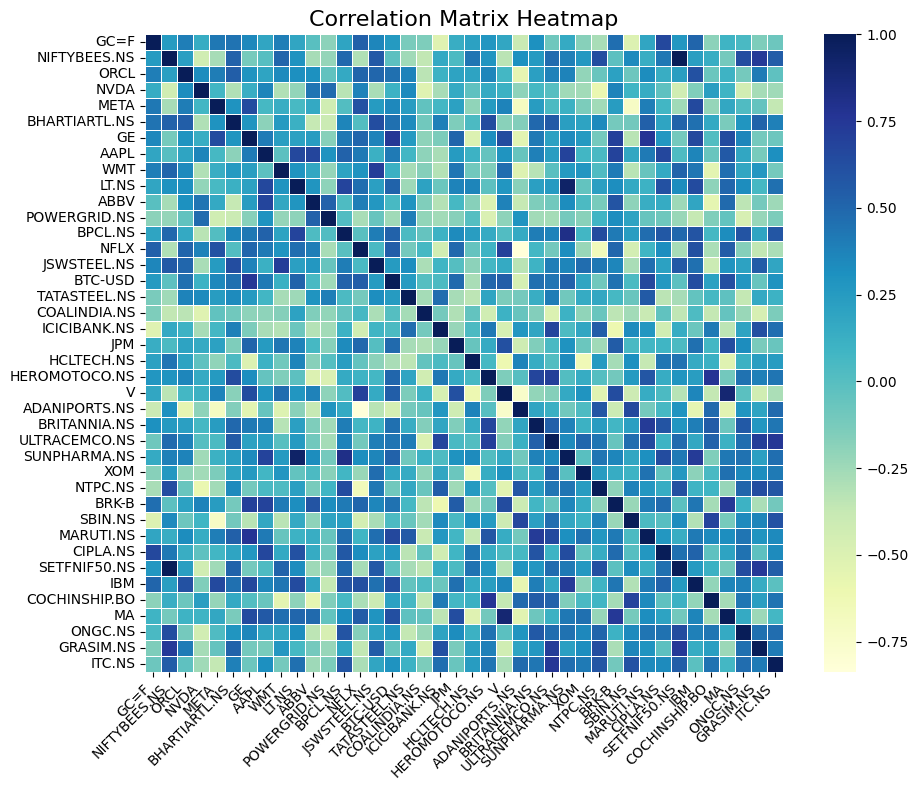

In [ ]:
import seaborn as sns
correlation_matrix=historical_returns_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=False,  # No values displayed
    cmap="YlGnBu",  # Custom color tone
    linewidths=0.5,  # Add lines between cells
    cbar=True,  # Show color bar
    square=True  # Ensure the plot is square
)
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()
